# WGCNA
weighted gene co-expression network analysis

using [new reference genome](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)

# Phase 1 

following [Hovrath Lab Tutorial](https://www.dropbox.com/scl/fo/4vqfiysan6rlurfo2pbnk/h?dl=0&e=1&preview=Consensus-NetworkConstruction-man.pdf&rlkey=thqg8wlpdn4spu3ihjuc1kmlu) and [Phase 2 analysis](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna/wgcna_p2.ipynb)

## 0. load libraries

In [2]:
library(tidyverse)
library(DESeq2)
library(WGCNA)
library(janitor) # for row_to_names()
library(zoo)
library(ComplexHeatmap)
library(circlize)
library(reshape)
library(fastDummies) # create 0/1 factor columns
library(ape) # for read.gff
library(cowplot) # for plot_grid()
library(grid)

In [3]:
# important setting, cannot omit
options(stringsAsFactors = FALSE)

In [4]:
# allow multi-threading within WGCNA
enableWGCNAThreads()

Allowing parallel execution with up to 63 working processes.


## 1. structure WGCNA input

**Expected input**:
- Rows = samples
- Columns = genes (or probes/features)
- Values = numeric expression values

### A. format vst normalized counts matrix

In [5]:
# counts matrix - sample x gene name
dataExpr <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.both_v_cont.csv')

# set gene name as row name
rownames(dataExpr) <- dataExpr$Gene

# format for wgcna
dataExpr <- dataExpr[,10:32] %>% # keep only vst expr
t() # transpose df 

dim(dataExpr)
head(dataExpr)

[1]    23 33903

,LOC144621260,LOC144621269,LOC111120925,Trnae-cuc,Trnae-cuc-2,Trnae-cuc-3,LOC144621283,LOC144621276,LOC111115920,LOC111113911,⋯,LOC144621425,LOC111114947,LOC111111216,LOC111111215,LOC111111213,LOC111114497,LOC111114498,LOC111112304,LOC144621306,LOC144621888
B1_Nu_O03,2271.417,497.32799,3.429848,0,0,0.0000000,841.1703,11807.252,316.4035,0,⋯,0,0,397.0049,194.6439,14436.231,189.49911,3295.227,1208.164,0.000000,104.610370
B2_Nu_O12,3803.795,19153.93441,17.229065,0,0,0.9571703,1032.7867,13820.582,249.8214,0,⋯,0,0,501.5572,574.3022,16226.908,435.51248,4089.989,1516.158,81.359474,21.057746
B4_Nu_O32,2282.646,9621.34007,22.650291,0,0,0.0000000,1121.6088,18011.175,223.9862,0,⋯,0,0,116.6071,443.7779,11003.008,104.02356,5069.471,1773.434,4.194498,1.677799
B5_Nu_O36,2565.496,23.98728,2.284503,0,0,0.0000000,885.2448,9461.268,390.6500,0,⋯,0,0,300.4121,390.6500,11236.326,66.25058,5513.647,2910.456,4.569005,6.853508
B6_Nu_O47,2768.445,91.36082,8.498681,0,0,0.0000000,1214.2490,8577.293,526.9182,0,⋯,0,0,412.1860,377.1290,9871.218,41.43107,3993.318,2594.222,2.124670,60.553100
C1_Nu_W01,2464.392,8474.20320,19.335456,0,0,0.0000000,950.9529,8337.976,251.3609,0,⋯,0,0,544.9083,603.7936,11193.471,76.46294,2189.301,1429.945,32.518722,75.584057


### B. identify and remove genes with missing data 
genes with too many NAs or zero-counts

In [6]:
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
gsg$allOK

dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
dim(dataExpr) # 23 samples x 28705 genes

 Flagging genes and samples with too many missing values...
  ..step 1
  ..Excluding 5198 genes from the calculation due to too many missing samples or zero variance.
  ..step 2


[1] FALSE

[1]    23 28705

### C. Sample size and gene filtering

removing low-variance genes first:

In [7]:
dataExpr <- dataExpr[, apply(dataExpr, 2, var) > quantile(apply(dataExpr, 2, var), 0.25)]
dim(dataExpr) # 23 samples x 26235 genes

[1]    23 21528

### D. Sample outlier detection

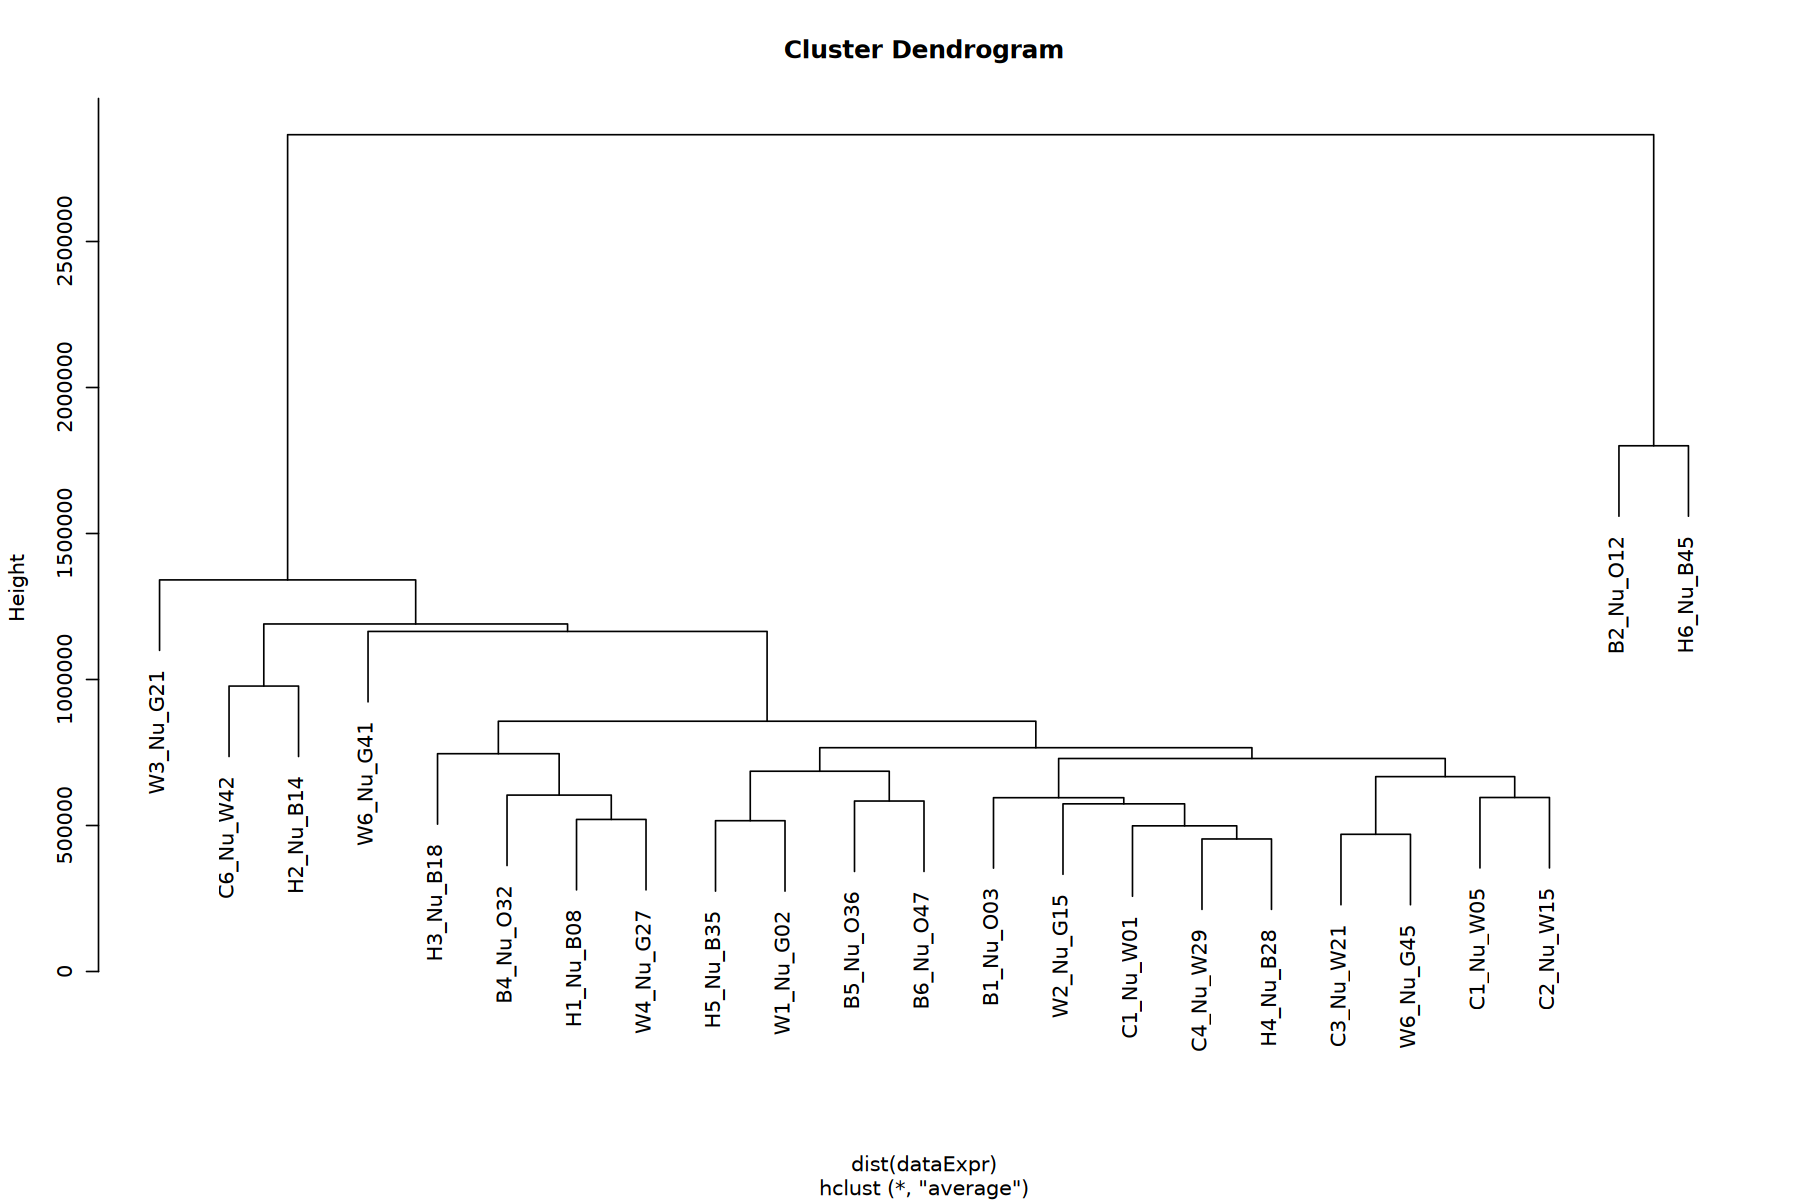

In [8]:
options(repr.plot.width = 15, repr.plot.height = 10)

sampleTree <- hclust(dist(dataExpr), method = "average")
plot(sampleTree)

obvious outliers - B2_Nu_O12 and H6_Nu_B45 - becuase it clusters above the rest of the tree and is separated from the main cluster - going to remove it from analysis

In [9]:
# remove 2 samples that are visual outliers
dataExpr <- dataExpr[rownames(dataExpr) != 'B2_Nu_O12', ]
dataExpr <- dataExpr[rownames(dataExpr) != 'H6_Nu_B45', ]

dim(dataExpr)

[1]    21 21528

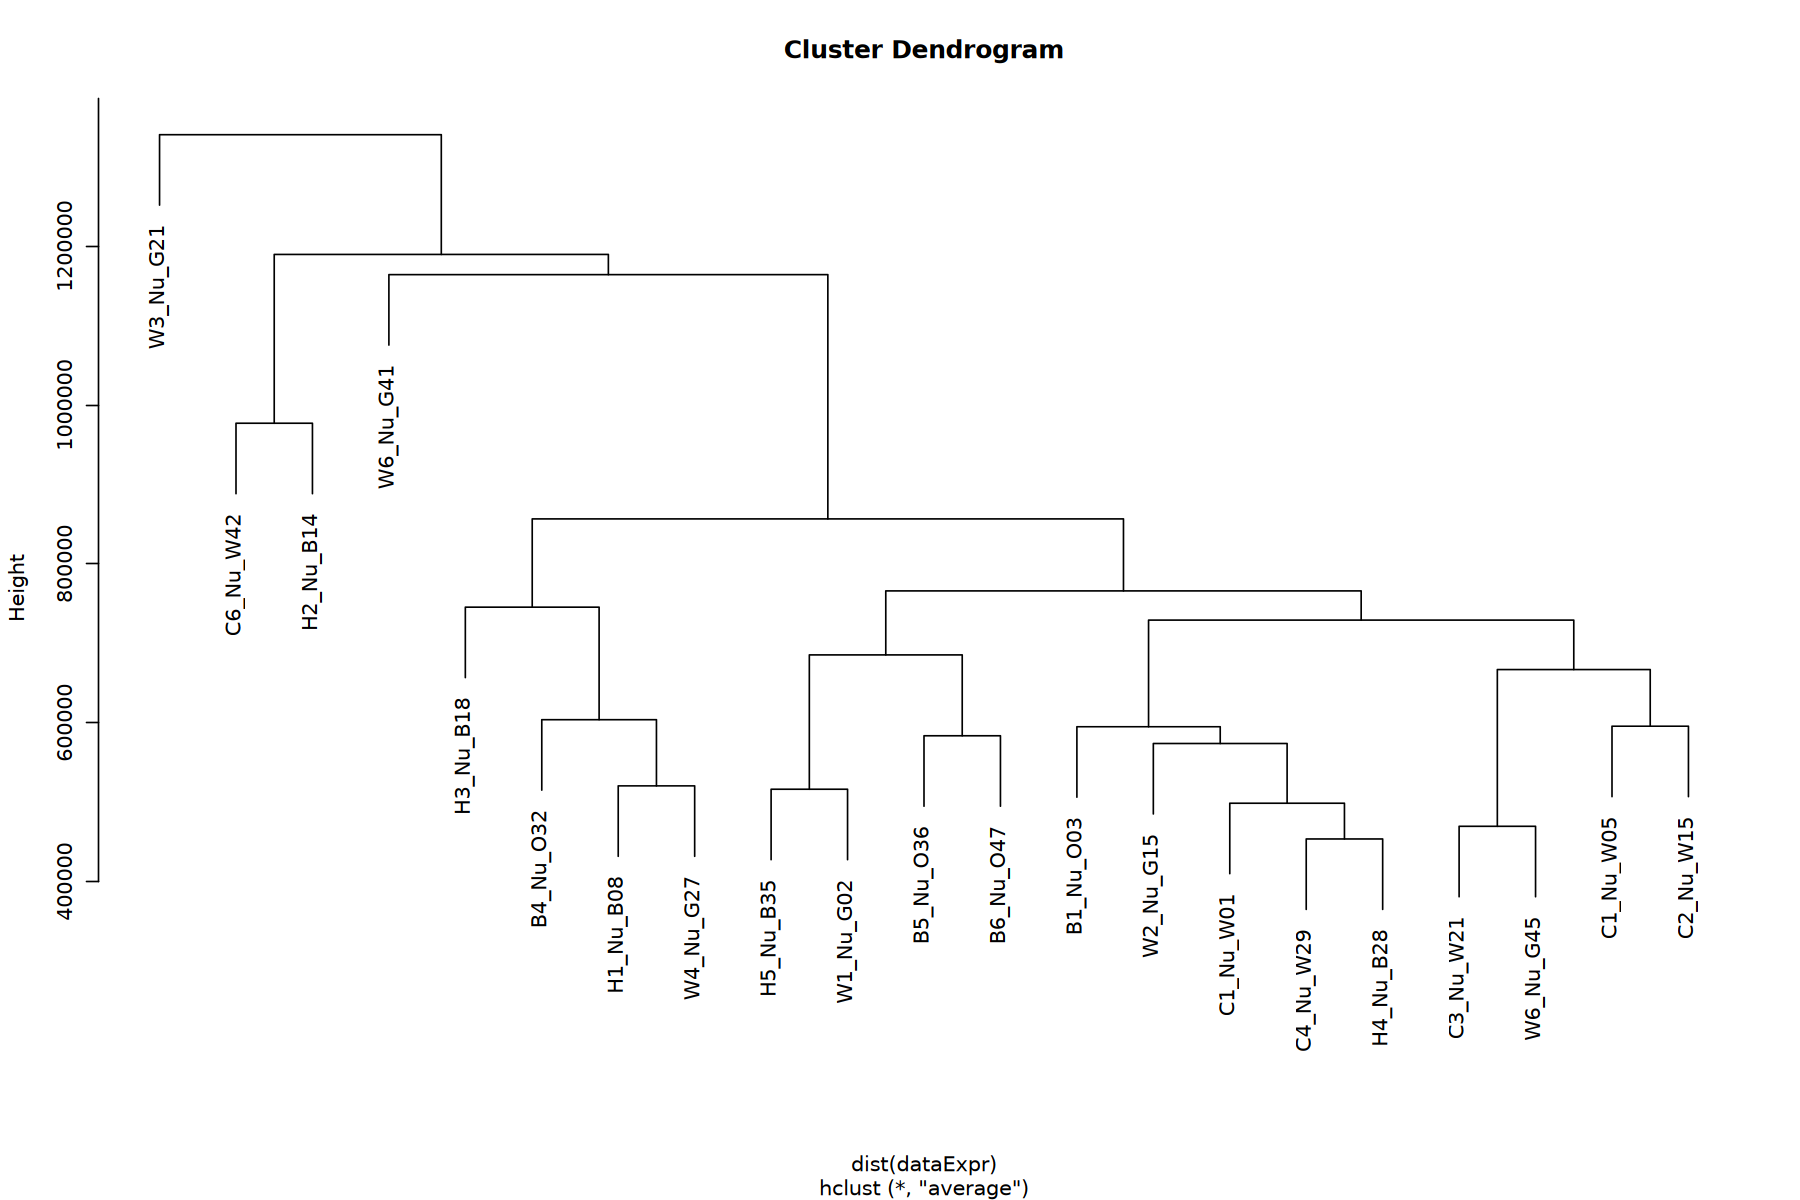

In [10]:
# replot without outliers
sampleTree <- hclust(dist(dataExpr), method = "average")
plot(sampleTree)

check again if things are okay

In [11]:
# QC check again
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
if (!gsg$allOK) {
  dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
}

gsg$allOK

 Flagging genes and samples with too many missing values...
  ..step 1
  ..Excluding 1 genes from the calculation due to too many missing samples or zero variance.
  ..step 2


[1] FALSE

In [12]:
# remove 2 samples that are visual outliers
dataExpr <- dataExpr[rownames(dataExpr) != 'W3_Nu_G21', ]

dim(dataExpr)

[1]    20 21527

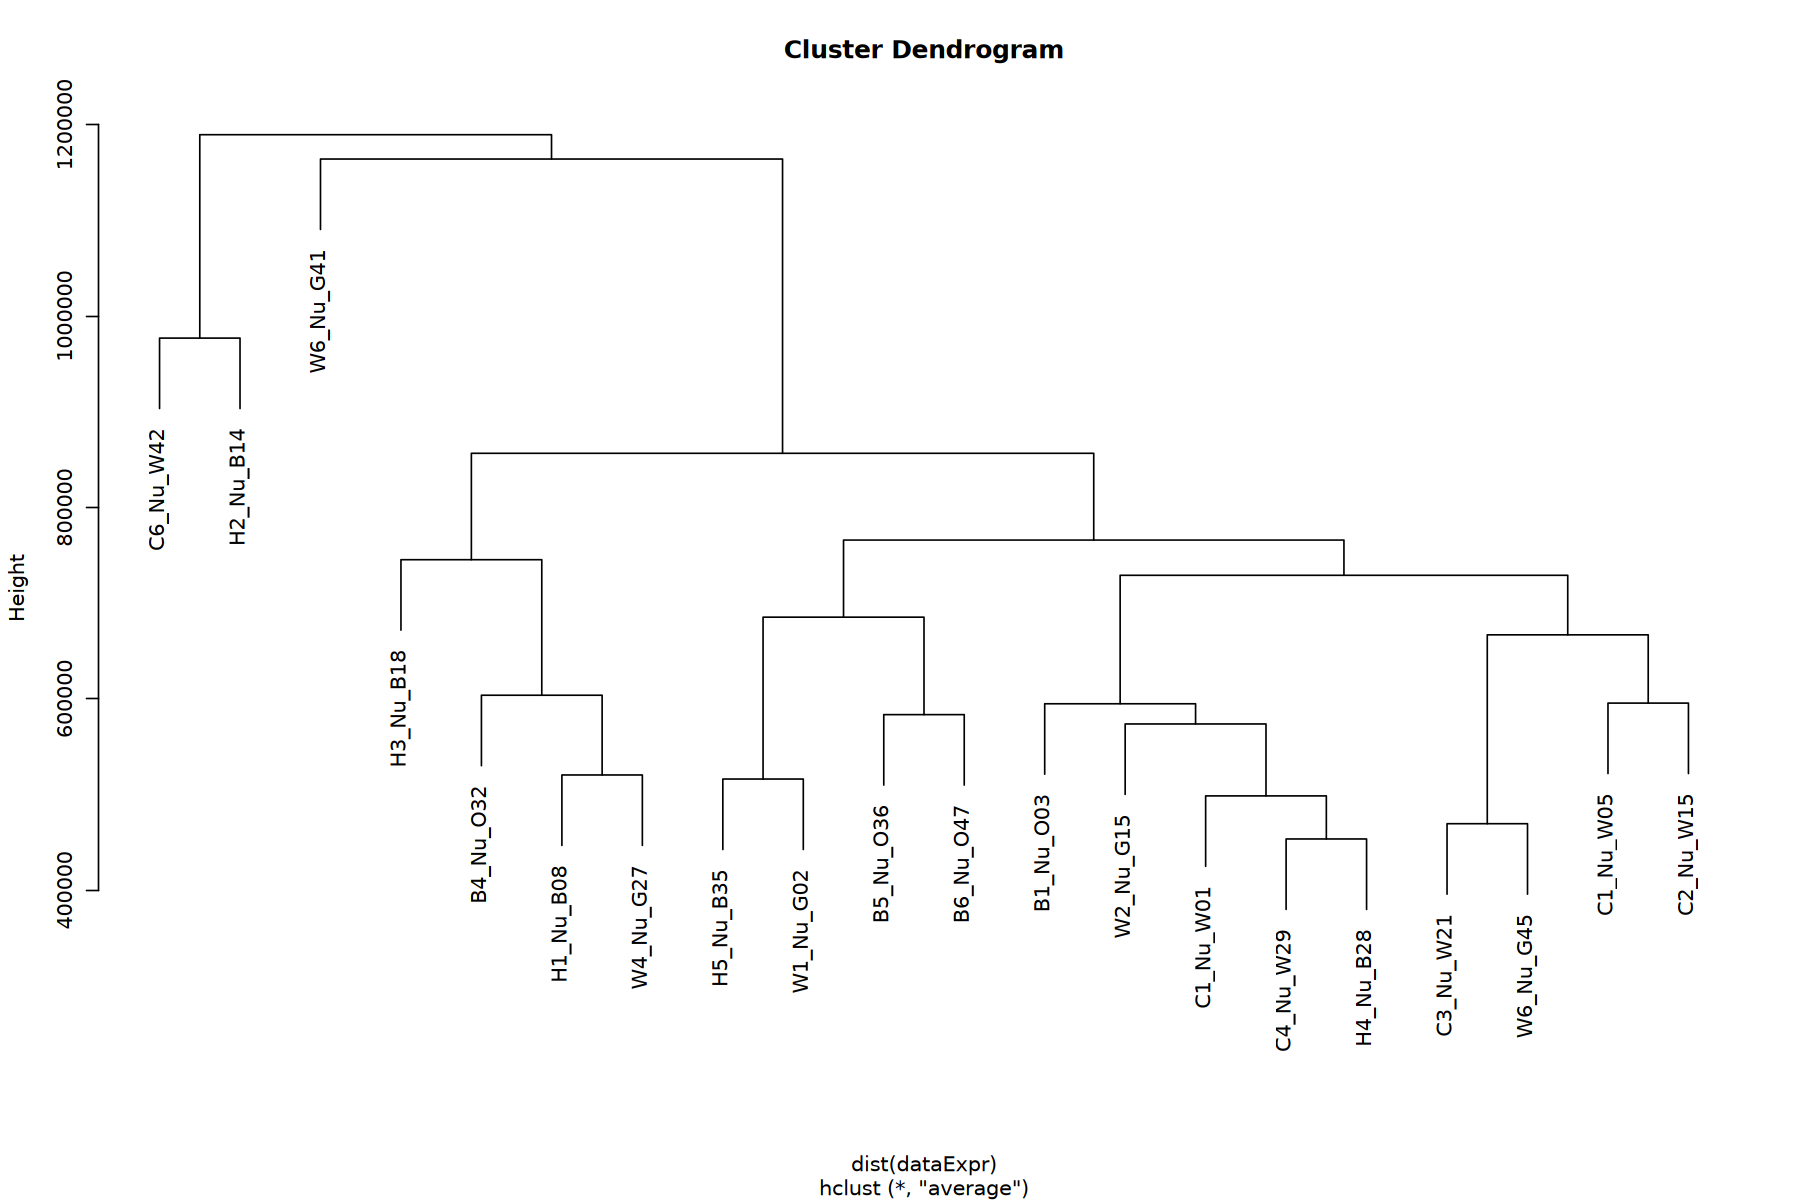

In [13]:
# replot without outliers
sampleTree <- hclust(dist(dataExpr), method = "average")
plot(sampleTree)

In [14]:
# QC check again
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
if (!gsg$allOK) {
  dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
}

gsg$allOK

 Flagging genes and samples with too many missing values...
  ..step 1


[1] TRUE

looks like removing that other sample worked out

### meta data
could add phenotypic data to this ...

In [15]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
filter(grepl("Nu", Sample)) # filter out phase 2 samples - only want phase 1

# setting samples as rownames and deleting col from df
rownames(meta) <- meta$Sample
meta <- meta[, !colnames(meta) %in% "Sample"]

# removing same samples as dataExpr
meta <- meta[rownames(meta) %in% rownames(dataExpr), ]

head(meta)
dim(meta) # 21 samples

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA
C1_Nu_W01,control,ambient,normoxic,1,NA,NA,NA,NA
C1_Nu_W05,control,ambient,normoxic,1,NA,NA,NA,NA


[1] 20  8

In [16]:
# double checking the samples in rownames are the same
all(rownames(meta) == rownames(dataExpr))

[1] TRUE

## 2. simple WGCNA network construction and module identification
start with simple, can progress to consensus if deemed necessary

In [17]:
# final QC check
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
if (!gsg$allOK) {
  dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
}

gsg$allOK

 Flagging genes and samples with too many missing values...
  ..step 1


[1] TRUE

In [18]:
#write.csv(colnames(dataExpr), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/p1.wgcna_UniversalGeneList.csv', row.names = FALSE)

### A. choose soft thresholding power (β)
analysis of network topology

In [19]:
powers <- c(1:20)
sft <- pickSoftThreshold(
  dataExpr,
  powerVector = powers,
  networkType = "signed",
  verbose = 5
)


pickSoftThreshold: will use block size 2078.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 2078 of 21527
   ..working on genes 2079 through 4156 of 21527
   ..working on genes 4157 through 6234 of 21527
   ..working on genes 6235 through 8312 of 21527
   ..working on genes 8313 through 10390 of 21527
   ..working on genes 10391 through 12468 of 21527
   ..working on genes 12469 through 14546 of 21527
   ..working on genes 14547 through 16624 of 21527
   ..working on genes 16625 through 18702 of 21527
   ..working on genes 18703 through 20780 of 21527
   ..working on genes 20781 through 21527 of 21527
   Power SFT.R.sq slope truncated.R.sq mean.k. median.k. max.k.
1      1   0.0651 30.70          0.975 10800.0   10800.0  11100
2      2   0.0447  7.07          0.940  5770.0    5770.0   6200
3      3   0.0148 -1.73          0.913  3280.0    3260.0   3840
4      4   0.0633 -2.01          0.872  1970.0    1940.0   2550
5      5   0.2250 -2.

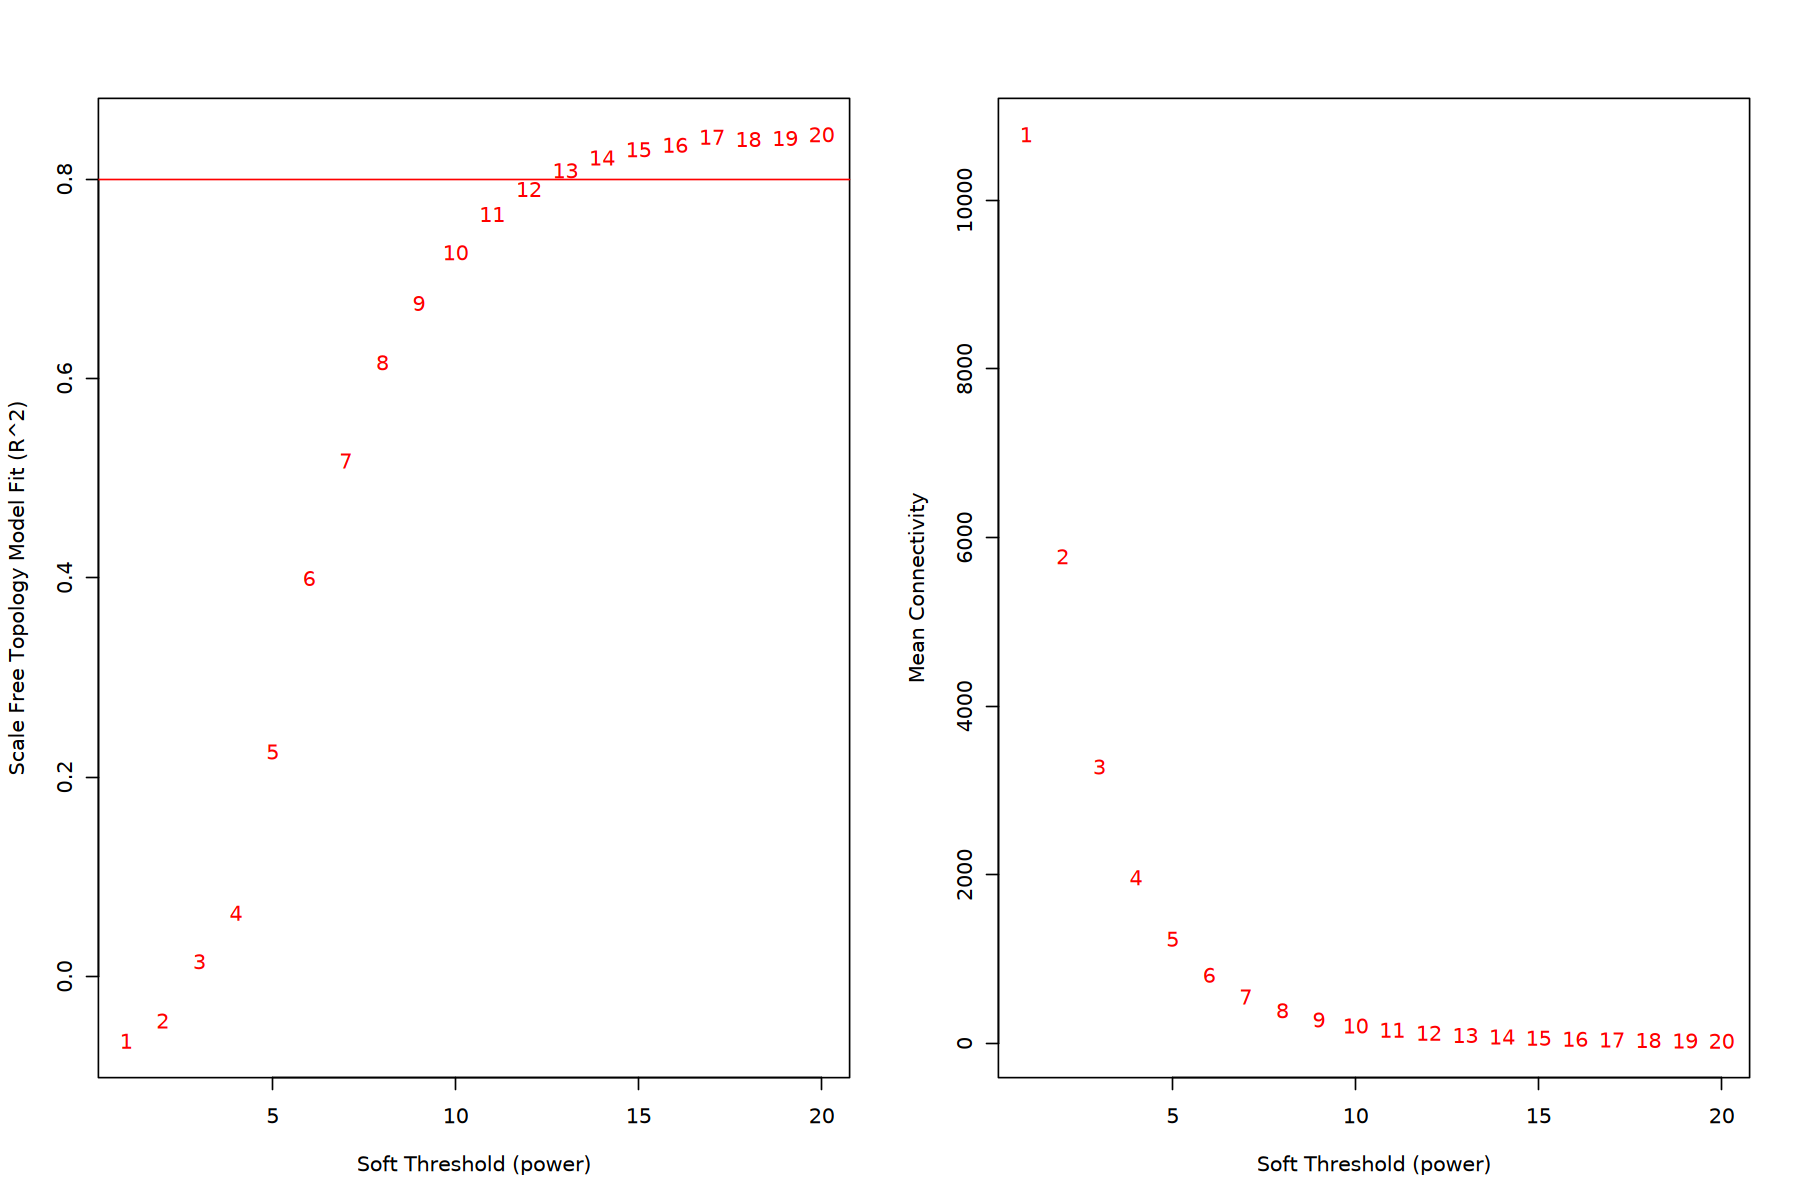

In [20]:
par(mfrow = c(1,2))
plot(
  sft$fitIndices[,1],
  -sign(sft$fitIndices[,3]) * sft$fitIndices[,2],
  xlab = "Soft Threshold (power)",
  ylab = "Scale Free Topology Model Fit (R^2)",
  type = "n"
)
text(
  sft$fitIndices[,1],
  -sign(sft$fitIndices[,3]) * sft$fitIndices[,2],
  labels = powers,
  col = "red"
)
abline(h = 0.8, col = "red")

plot(
  sft$fitIndices[,1],
  sft$fitIndices[,5],
  xlab = "Soft Threshold (power)",
  ylab = "Mean Connectivity",
  type = "n"
)
text(
  sft$fitIndices[,1],
  sft$fitIndices[,5],
  labels = powers,
  col = "red"
)


#### left plot - scale-free topology
the red line is where R^2 is 0.8 - you want the lowest power that reaches this - 13 is just above 0.8 and anything after 13 plateaus

#### right plot - mean connectivity
connectivity should not collapse to 0 - by power ~14, the connectivity approaches 0

based on this, I think power of 13 should be appropriate

### B. co-expression similarity and adjacency

creating adjacency matrix

In [21]:
softPower <- 13

calculate co-expression adjacency using soft threshold power of 10

doing signed like the phase 2 vs. phase 2 analysis

In [22]:
# signed
adjacency_sign <- adjacency(dataExpr, power = softPower, type = 'signed') 
head(adjacency_sign)

,LOC144621260,LOC144621269,LOC111120925,LOC144621283,LOC144621276,LOC111115920,LOC144621308,LOC111112629,LOC111102827,LOC111102829,⋯,LOC111110910,LOC111110817,LOC111111216,LOC111111215,LOC111111213,LOC111114497,LOC111114498,LOC111112304,LOC144621306,LOC144621888
LOC144621260,1.000000e+00,5.940017e-03,1.893760e-03,6.583279e-05,1.918025e-04,4.947604e-05,2.991409e-05,3.310616e-04,2.032849e-05,3.127408e-04,⋯,3.658712e-04,1.453778e-03,2.035499e-04,1.269904e-04,4.791632e-05,3.281733e-04,1.581648e-05,1.145352e-05,3.170804e-04,3.849745e-05
LOC144621269,5.940017e-03,1.000000e+00,2.029276e-05,1.319616e-05,5.671609e-04,1.153502e-06,2.660707e-03,1.517867e-04,7.776238e-04,3.672081e-04,⋯,1.652954e-02,5.613275e-03,1.039872e-03,7.810123e-02,1.694876e-06,3.112594e-04,2.844205e-06,1.389662e-05,8.400045e-04,1.066028e-05
LOC111120925,1.893760e-03,2.029276e-05,1.000000e+00,8.109334e-04,4.108759e-04,2.147996e-07,8.001960e-05,2.181513e-05,3.246141e-04,1.791008e-06,⋯,1.911546e-04,1.855539e-05,1.115441e-06,8.048337e-06,5.675690e-02,1.380894e-05,1.546489e-02,7.177558e-07,1.016615e-05,6.281749e-05
LOC144621283,6.583279e-05,1.319616e-05,8.109334e-04,1.000000e+00,1.524205e-02,5.909734e-04,8.108421e-06,4.951467e-03,1.556343e-06,1.311341e-04,⋯,3.186638e-04,4.574779e-05,1.419593e-03,5.475716e-06,6.129186e-04,2.604898e-03,7.038689e-05,6.126997e-06,1.928285e-04,1.246975e-02
LOC144621276,1.918025e-04,5.671609e-04,4.108759e-04,1.524205e-02,1.000000e+00,1.160080e-07,9.216713e-05,5.789313e-02,7.220100e-05,5.974971e-03,⋯,4.554268e-04,2.377568e-05,3.116098e-06,6.275569e-05,7.442688e-03,3.032018e-02,7.938783e-04,1.163655e-07,1.972278e-05,3.213418e-04
LOC111115920,4.947604e-05,1.153502e-06,2.147996e-07,5.909734e-04,1.160080e-07,1.000000e+00,2.018228e-06,1.456098e-04,1.395157e-06,1.199631e-05,⋯,6.259771e-05,4.673891e-04,1.065557e-02,1.995791e-04,8.576738e-08,1.893189e-05,9.631182e-06,5.091864e-03,5.980859e-06,1.748539e-04


In [23]:
#write.csv(data.frame(gene = rownames(adjacency_sign)), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/p1.wgcna_UniversalGeneList.csv', row.names = FALSE)

### C. Topological Overlap Matrix (TOM)
transform adjacency into TOM to minimize effects of noise and spurious associations - calculate corresponding dissimilarity

In [24]:
## SIGNED
# turn adjacency into topological overlap
TOM_sign <- TOMsimilarity(adjacency_sign)
head(TOM_sign)

# calculate dissimilarity
dissTOM_sign <- 1-TOM_sign
head(dissTOM_sign)

..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.


1.000000000,0.0479990980,0.0163955147,0.001088382,3.266649e-03,1.112543e-03,0.0027208712,0.0012501597,0.0011931190,0.0012708121,⋯,0.003527665,0.003804841,0.0033660008,0.0067924938,2.352071e-03,0.0025798844,0.0015259270,0.0007433564,0.0032255816,0.0012629229
0.047999098,1.0000000000,0.0006525919,0.001248772,8.096203e-03,2.047831e-04,0.0132333132,0.0058070522,0.0019358397,0.0042901990,⋯,0.062783266,0.019140377,0.0081666895,0.1461429108,2.740614e-04,0.0018197906,0.0002117751,0.0002739899,0.0039028088,0.0006506528
0.016395515,0.0006525919,1.0000000000,0.012356676,1.312734e-02,1.651994e-04,0.0050412748,0.0025851379,0.0074346727,0.0008923070,⋯,0.005632844,0.001534088,0.0002081934,0.0008511748,7.722187e-02,0.0011598450,0.0359827387,0.0005689740,0.0005153252,0.0014792840
0.001088382,0.0012487722,0.0123566757,1.000000000,1.909864e-02,2.347271e-03,0.0008838421,0.0061299827,0.0011642120,0.0011191092,⋯,0.001278841,0.001208274,0.0078536424,0.0004194161,7.988887e-03,0.0232555910,0.0024734002,0.0004962376,0.0012677586,0.0336294492
0.003266649,0.0080962029,0.0131273357,0.019098641,1.000000e+00,7.380224e-05,0.0020889208,0.0199193515,0.0018409448,0.0075285416,⋯,0.005616940,0.001241102,0.0013486877,0.0021426007,1.275441e-02,0.0209201753,0.0047964779,0.0001280454,0.0005280343,0.0047722734
0.001112543,0.0002047831,0.0001651994,0.002347271,7.380224e-05,1.000000e+00,0.0003571504,0.0009372477,0.0006800685,0.0009240629,⋯,0.001329720,0.006387926,0.0039845430,0.0013661849,7.210898e-05,0.0004191557,0.0015001069,0.0273060519,0.0009101123,0.0006587781


0.0000000,0.9520009,0.9836045,0.9989116,0.9967334,0.9988875,0.9972791,0.9987498,0.9988069,0.9987292,⋯,0.9964723,0.9961952,0.9966340,0.9932075,0.9976479,0.9974201,0.9984741,0.9992566,0.9967744,0.9987371
0.9520009,0.0000000,0.9993474,0.9987512,0.9919038,0.9997952,0.9867667,0.9941929,0.9980642,0.9957098,⋯,0.9372167,0.9808596,0.9918333,0.8538571,0.9997259,0.9981802,0.9997882,0.9997260,0.9960972,0.9993493
0.9836045,0.9993474,0.0000000,0.9876433,0.9868727,0.9998348,0.9949587,0.9974149,0.9925653,0.9991077,⋯,0.9943672,0.9984659,0.9997918,0.9991488,0.9227781,0.9988402,0.9640173,0.9994310,0.9994847,0.9985207
0.9989116,0.9987512,0.9876433,0.0000000,0.9809014,0.9976527,0.9991162,0.9938700,0.9988358,0.9988809,⋯,0.9987212,0.9987917,0.9921464,0.9995806,0.9920111,0.9767444,0.9975266,0.9995038,0.9987322,0.9663706
0.9967334,0.9919038,0.9868727,0.9809014,0.0000000,0.9999262,0.9979111,0.9800806,0.9981591,0.9924715,⋯,0.9943831,0.9987589,0.9986513,0.9978574,0.9872456,0.9790798,0.9952035,0.9998720,0.9994720,0.9952277
0.9988875,0.9997952,0.9998348,0.9976527,0.9999262,0.0000000,0.9996428,0.9990628,0.9993199,0.9990759,⋯,0.9986703,0.9936121,0.9960155,0.9986338,0.9999279,0.9995808,0.9984999,0.9726939,0.9990899,0.9993412


### D. Call the hierarchical clustering function - plot the tree
hierarchical clustering tree (dendrogram) of genes

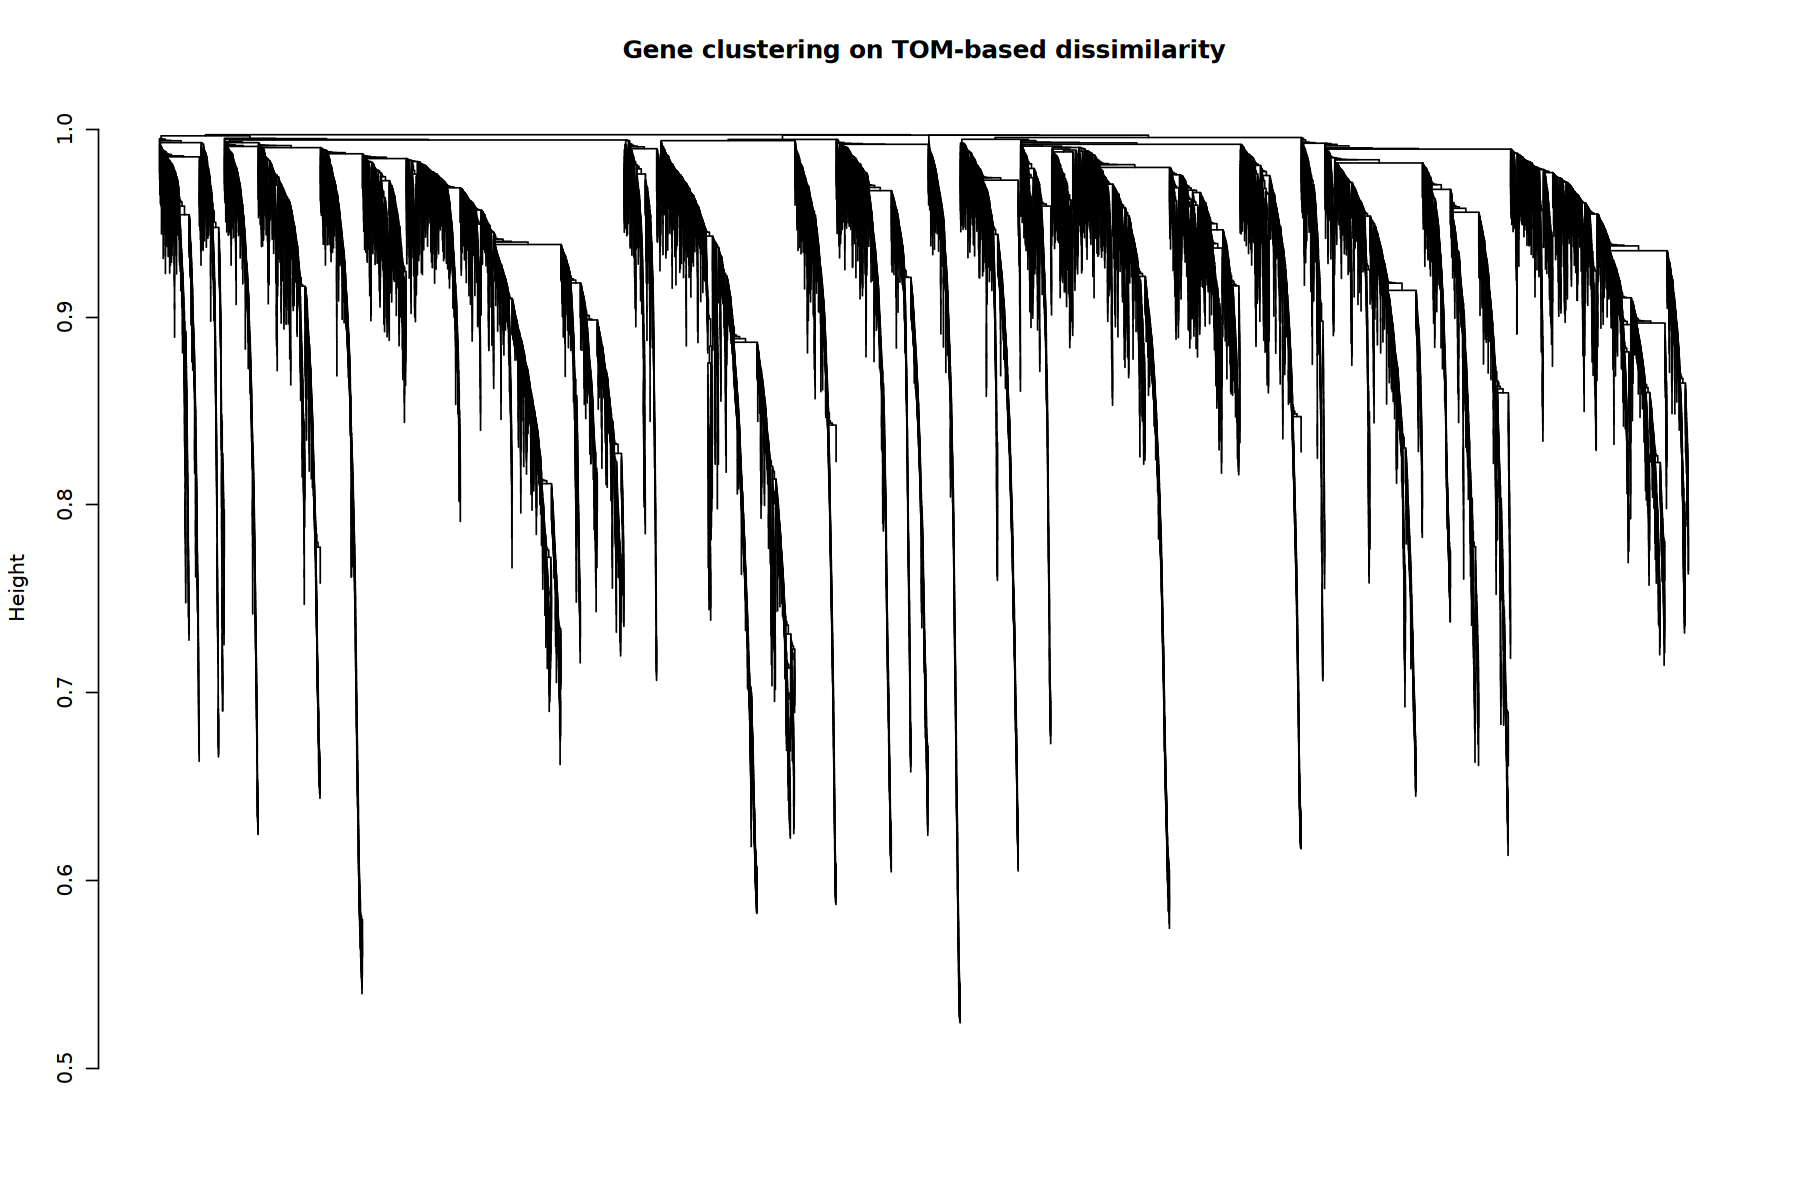

In [25]:
# call hierarchical clustering function
geneTree_sign = hclust(as.dist(dissTOM_sign), method = "average")

# plot the dendrogram
plot(geneTree_sign, xlab="", sub="", main = "Gene clustering on TOM-based dissimilarity",labels = FALSE, hang = 0.04)

each leaf (short vertical line) corresponds to a gene - branches group together densely interconnected, highly co-expressed genes

module identification = cutting branches off the dendrogram

### E. module identification

set minimum module size - this is the smallest number of genes allowed to be put into a module 

then use Dynamic Tree Cut which is the default method for branch cutting and module detection

In [26]:
# would like large modules, so we set the minimum module size relatively high:
minModuleSize <- 100

## SIGNED
# Module identification using dynamic tree cut:
dynamicMods_sign <- cutreeDynamic(dendro = geneTree_sign, distM = dissTOM_sign, 
                             deepSplit = 2, pamRespectsDendro = FALSE,
                             minClusterSize = minModuleSize)
table(dynamicMods_sign) # number of genes per module

 ..cutHeight not given, setting it to 0.994  ===>  99% of the (truncated) height range in dendro.
 ..done.


dynamicMods_sign
   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
1346 1281 1261 1114 1038 1026  871  867  837  784  760  733  732  721  603  599 
  17   18   19   20   21   22   23   24   25   26   27   28   29   30   31   32 
 562  556  497  464  451  437  423  412  396  330  310  305  294  287  279  254 
  33   34   35   36 
 216  189  150  142 

36 modules generated

convert numeric network to colors and plots dendrogram:

dynamicColors_sign
         black           blue          brown           cyan      darkgreen 
           871           1281           1261            721            437 
      darkgrey    darkmagenta darkolivegreen     darkorange        darkred 
           412            189            216            330            451 
 darkturquoise          green    greenyellow         grey60      lightcyan 
           423           1038            760            562            599 
    lightgreen    lightyellow        magenta   midnightblue         orange 
           556            497            837            603            396 
 paleturquoise           pink         purple            red      royalblue 
           279            867            784           1026            464 
   saddlebrown         salmon        sienna3        skyblue      steelblue 
           294            732            150            305            287 
           tan      turquoise         violet          white         y

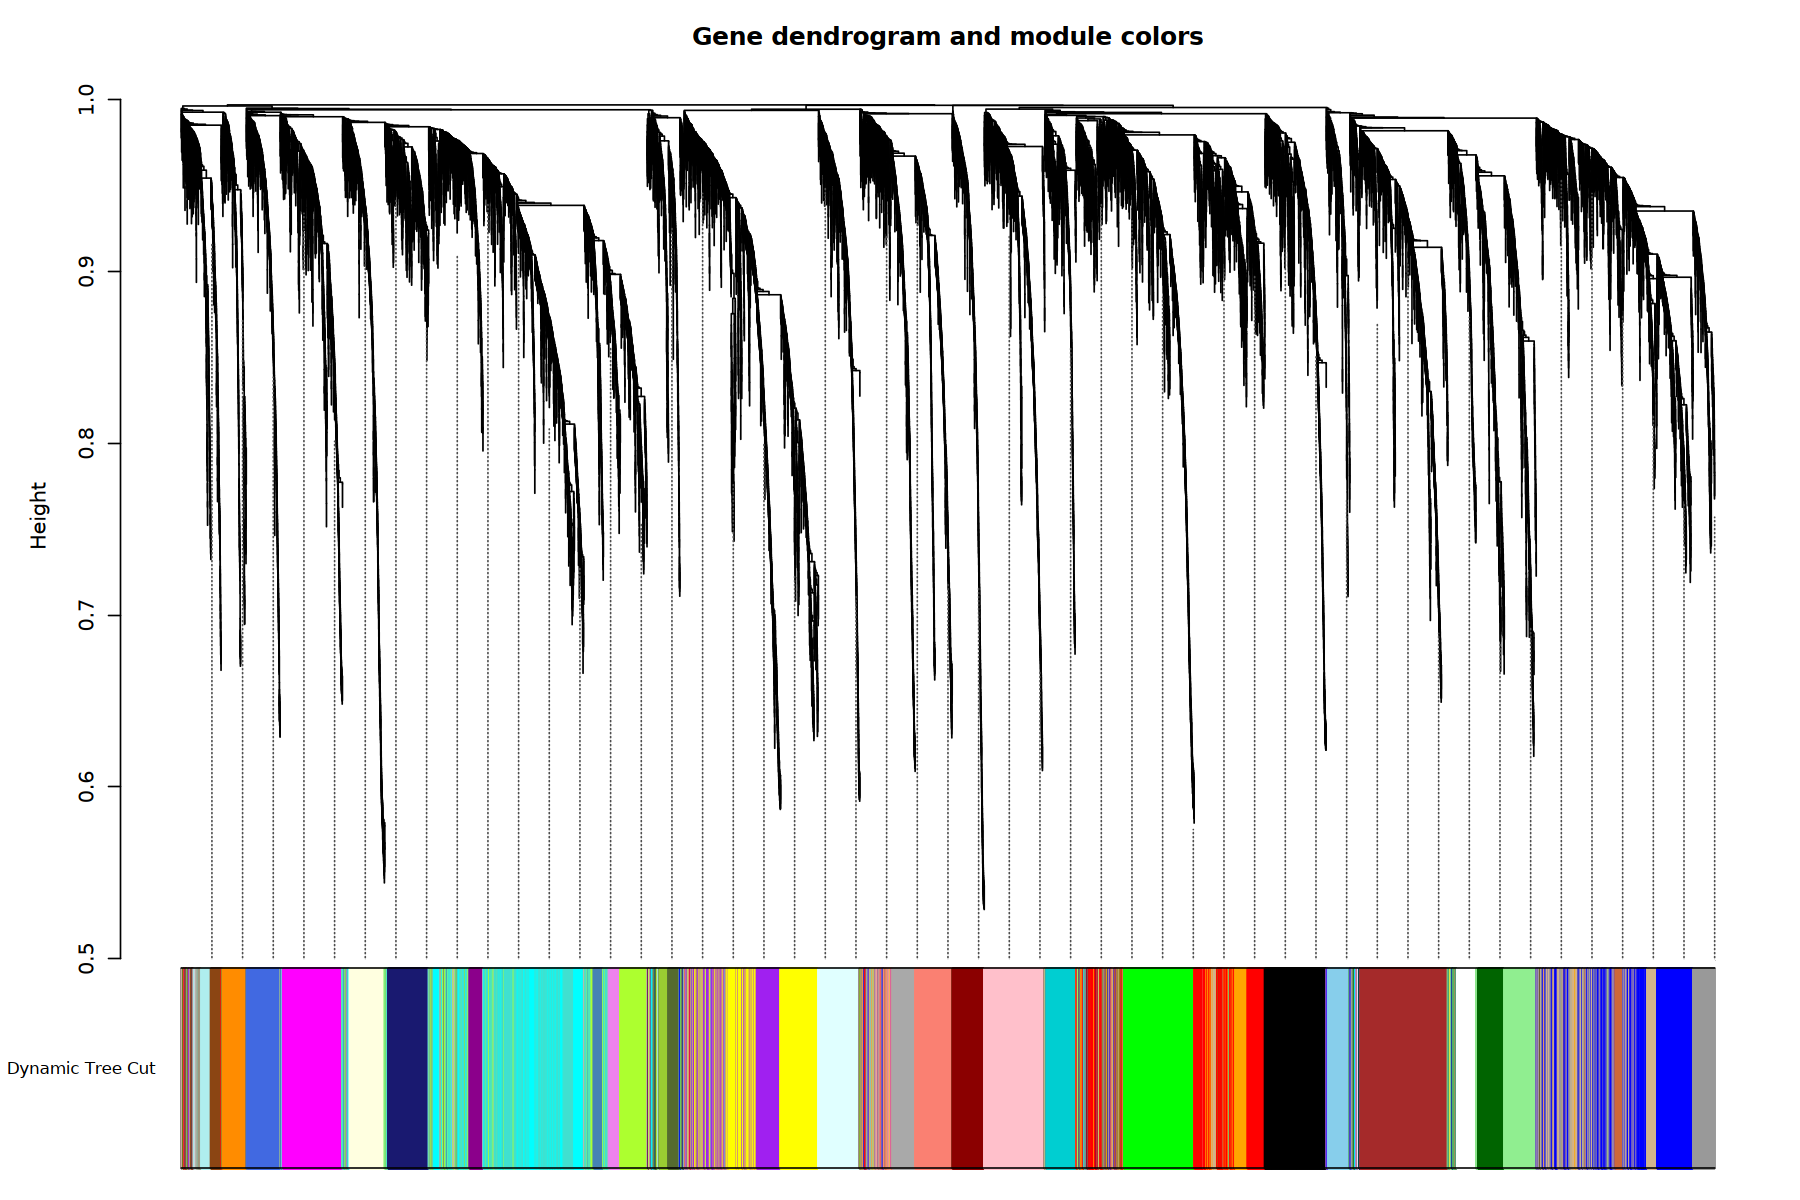

In [27]:
## SIGNED
# Convert numeric lables into colors
dynamicColors_sign <- labels2colors(dynamicMods_sign)
table(dynamicColors_sign)

# Plot the dendrogram and colors underneath
plotDendroAndColors(geneTree_sign, dynamicColors_sign, "Dynamic Tree Cut",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05,
                    main = "Gene dendrogram and module colors")


### F. merging modules whose GE profiles are similar

this is based on eigengenes, which is the first principal component of a given a gene expression matrix/module that acts as a representative summary profile for a gene module or cluster

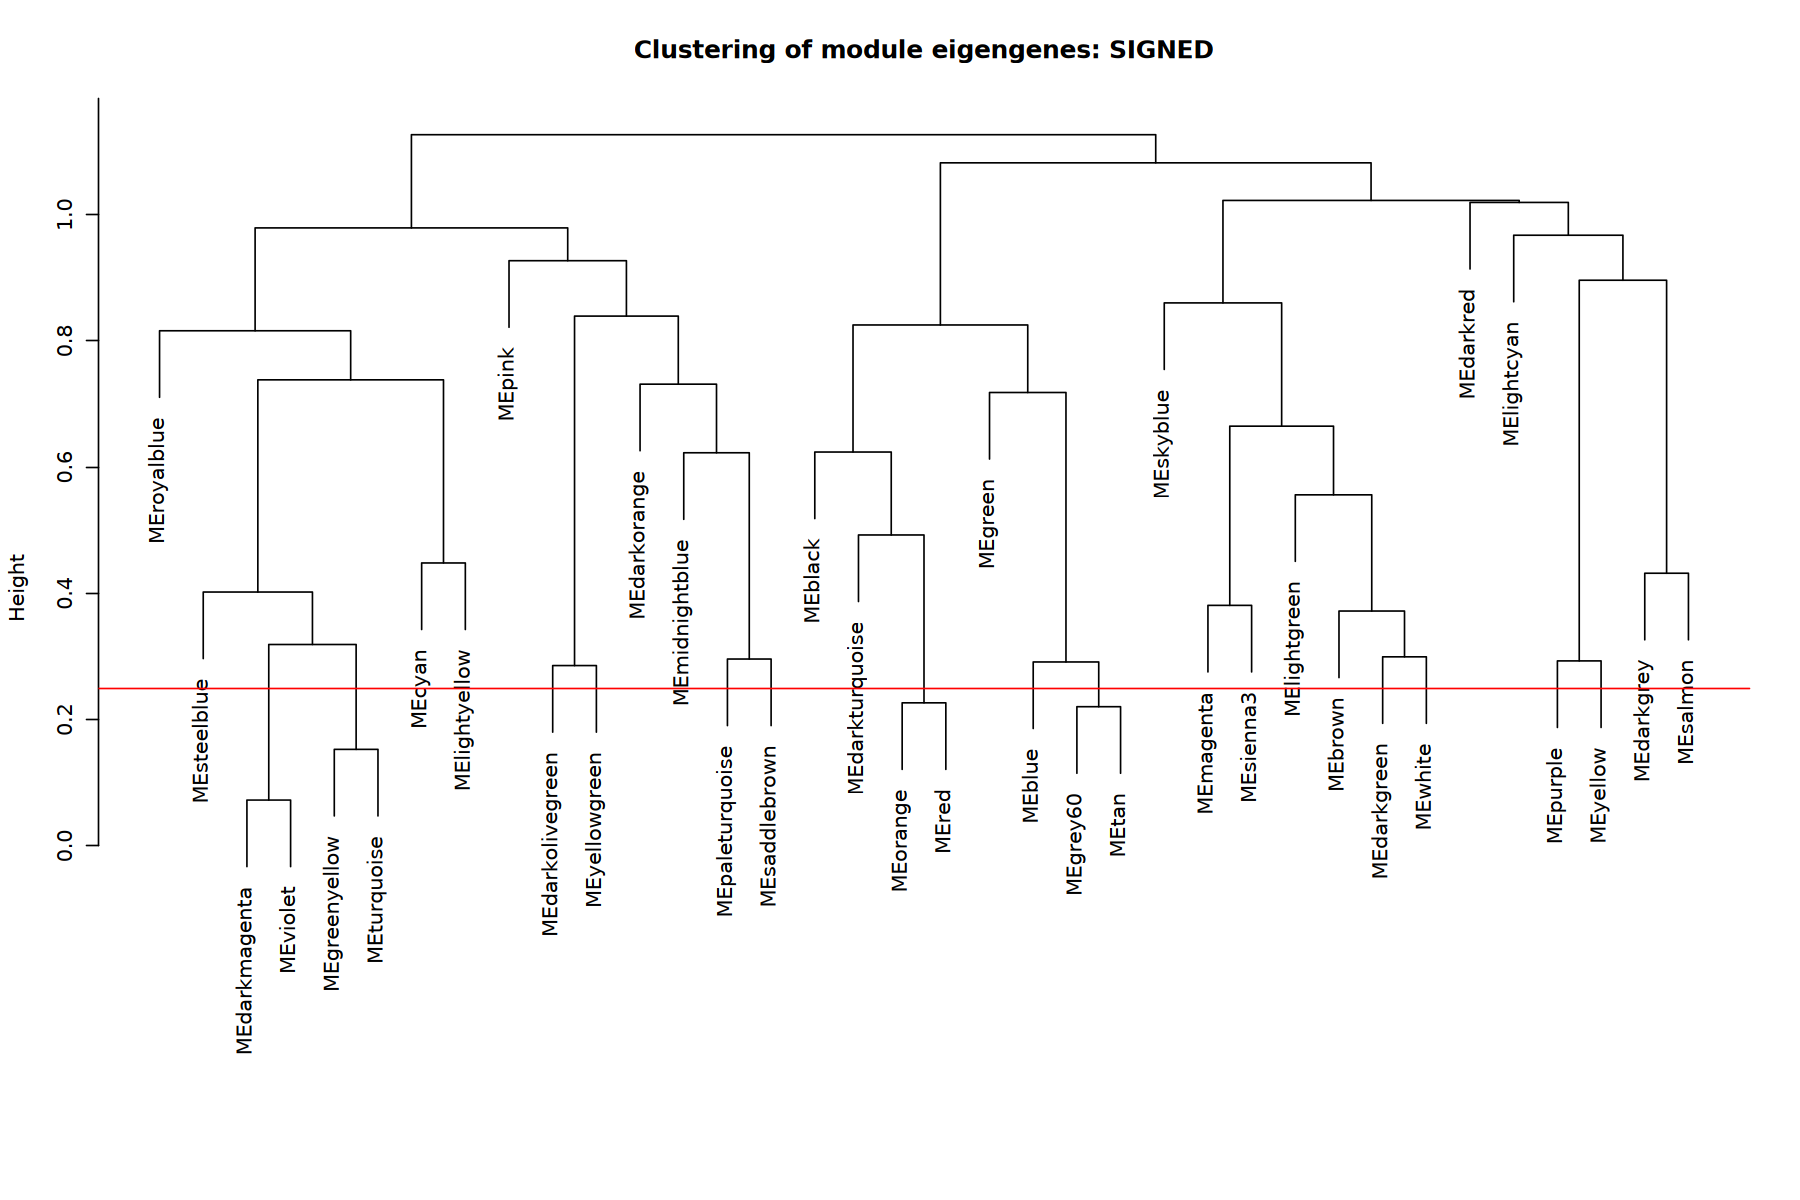

In [28]:
## SIGNED
# Calculate eigengenes
MEList_sign <- moduleEigengenes(dataExpr, colors = dynamicColors_sign)
MEs_sign <- MEList_sign$eigengenes

# Calculate dissimilarity of module eigengenes
MEDiss_sign <- 1-cor(MEs_sign)

# Cluster module eigengenes
METree_sign <- hclust(as.dist(MEDiss_sign), method = "average")

# Plot the result

# height cutoff of 0.25 - corresponds to a correlation of 0.75 to merge
MEDissThres <- 0.25

# Plot the cut line into the dendrogram
plot(METree_sign, main = "Clustering of module eigengenes: SIGNED", xlab = "", sub = "")
abline(h=MEDissThres, col = "red")

any branch with more than 75% correlation are related and will be merged - so blue and purple modules will be merged

 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 36 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 32 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 32 module eigengenes in given set.


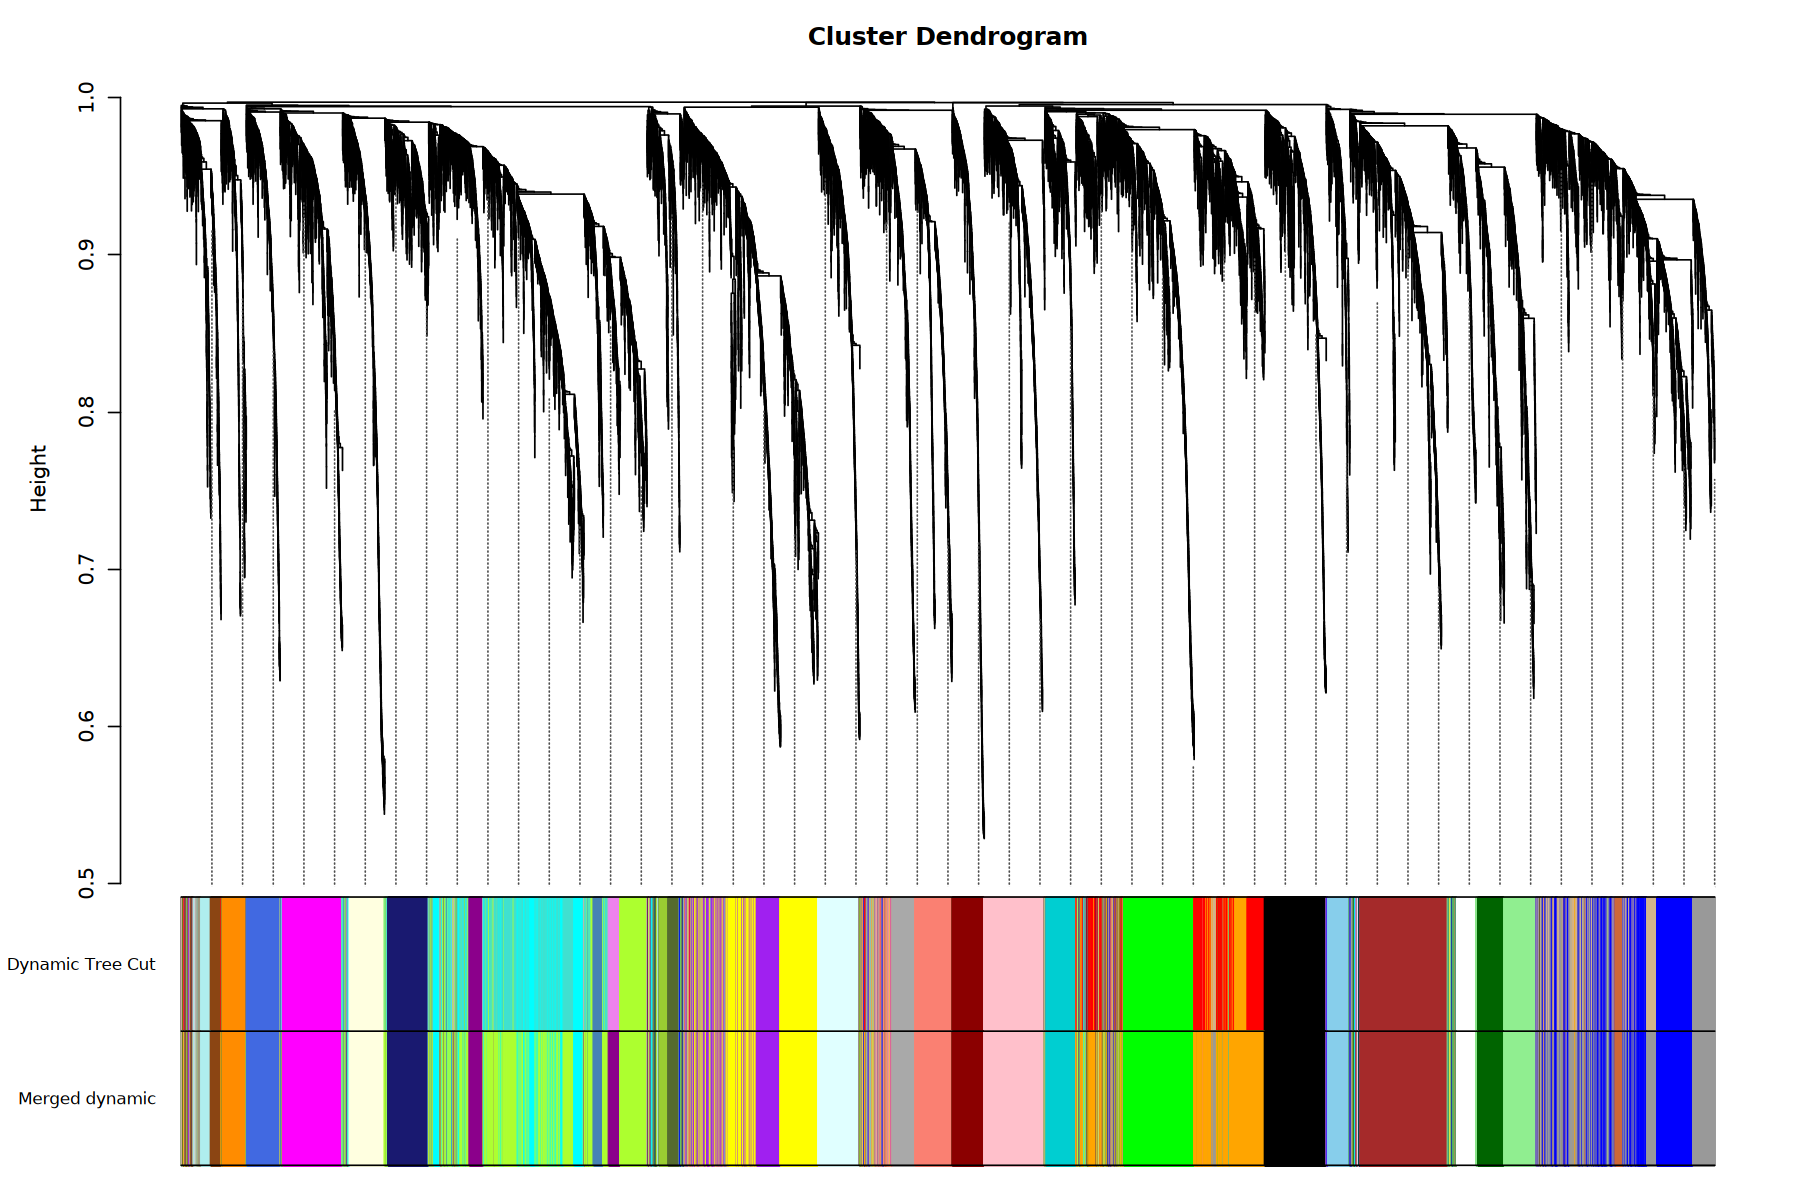

In [29]:
## SIGNED
# Call an automatic merging function
merge_sign <- mergeCloseModules(dataExpr, dynamicColors_sign, cutHeight = MEDissThres, verbose = 3)

# The merged module colors
mergedColors_sign <- merge_sign$colors

# Eigengenes of the new merged modules:
mergedMEs_sign <- merge_sign$newMEs

# plot merged module colors
plotDendroAndColors(geneTree_sign, cbind(dynamicColors_sign, mergedColors_sign), 
                    c("Dynamic Tree Cut", "Merged dynamic"),
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)

In [30]:
png("/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/mergedColors_dendrogram_p1.png", 
    width = 20, height = 12, units = "in", res = 300)

plotDendroAndColors(geneTree_sign, cbind(dynamicColors_sign, mergedColors_sign), 
                    c("Dynamic Tree Cut", "Merged dynamic"),
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)
dev.off()

png 
  2

In [31]:
table(mergedColors_sign)

mergedColors_sign
         black           blue          brown           cyan      darkgreen 
           871           1281           1261            721            437 
      darkgrey    darkmagenta darkolivegreen     darkorange        darkred 
           412            443            216            330            451 
 darkturquoise          green    greenyellow         grey60      lightcyan 
           423           1038           2106           1295            599 
    lightgreen    lightyellow        magenta   midnightblue         orange 
           556            497            837            603           1422 
 paleturquoise           pink         purple      royalblue    saddlebrown 
           279            867            784            464            294 
        salmon        sienna3        skyblue      steelblue          white 
           732            150            305            287            310 
        yellow    yellowgreen 
          1114            142 

32 modules ranging from 142 - 2106 genes

1295 genes were unassigned to a module (grey60)

In [32]:
# Recalculate MEs (module eigengenes) with color labels

MEs0 <- moduleEigengenes(dataExpr, mergedColors_sign)$eigengenes # create module eigengenes

MEs <- orderMEs(MEs0) # order so more similar modules are closer together
head(MEs)

,MElightyellow,MEcyan,MEmagenta,MEdarkorange,MEpaleturquoise,MEsaddlebrown,MEroyalblue,MEdarkolivegreen,MEyellowgreen,MEmidnightblue,⋯,MEgrey60,MEskyblue,MElightgreen,MEbrown,MEdarkgreen,MEwhite,MEpurple,MEyellow,MEdarkgrey,MEsalmon
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_Nu_O03,-0.04666700,0.22493399,-0.03692267,-0.05416260,-0.09348833,-0.08832140,0.964987877,-0.05421614,-0.05454344,0.05583547,⋯,-0.134819333,-0.10597244,-0.12086291,0.011084563,-0.1612395,-0.06249493,-0.09581976,-0.25241506,-0.05488904,-0.07372093
B4_Nu_O32,-0.04121190,-0.25580592,-0.04530235,-0.06765706,-0.08706743,-0.01018376,-0.021600694,-0.09120448,-0.03284026,-0.15114269,⋯,-0.050883942,-0.07482391,-0.04270932,0.027549552,-0.1342108,0.26331243,-0.02537243,0.23356899,0.96764116,0.48733261
B5_Nu_O36,-0.05308644,-0.12487964,-0.08049208,-0.07255712,-0.07824445,-0.05251726,-0.048096767,0.02355230,-0.02644965,-0.05168154,⋯,0.165902880,-0.04100993,-0.12710337,0.002670778,-0.1454705,-0.24106628,-0.09226893,-0.25227904,-0.09191963,-0.08714786
B6_Nu_O47,-0.05621793,-0.10402877,-0.12481175,-0.06292044,-0.08721741,-0.05132208,-0.077088035,-0.04294806,-0.11538466,0.11953532,⋯,0.043180927,-0.02672779,-0.08171814,-0.089282744,-0.1574907,-0.16818790,-0.07059880,-0.23178109,-0.06348716,-0.05485089
C1_Nu_W01,0.96940532,0.50756366,-0.04632018,-0.06099262,-0.10255346,-0.10745149,0.007304977,-0.06854692,-0.05760500,0.09377648,⋯,-0.165152661,-0.09418414,-0.07851573,-0.139612252,-0.1558020,-0.14349596,-0.02389631,0.19845806,-0.05516756,-0.08380267
C1_Nu_W05,-0.04326630,-0.09040951,-0.06705566,-0.06349107,0.29645643,0.01893473,-0.032969051,0.95898500,0.67279044,0.07574538,⋯,0.001246999,-0.04933011,-0.02908384,-0.024733534,0.2327694,0.06949745,-0.07365726,-0.08434951,-0.05695886,-0.07882691


In [33]:
#write.csv(MEs, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/p1.wgcna_ModuleEigengenes.csv')

## 3. quantifying module-trait associations
identify modules that are significantly associated with treatment exposures or measured traits (like growth)

### A. read in and format metadata

#### treatment data

In [34]:
# read in phase info
dataMeta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')

# keep only samples seen in dataExpr
dataMeta <- dataMeta[dataMeta$Sample %in% rownames(dataExpr),] 

# set sample as rownames
rownames(dataMeta) <- dataMeta$Sample

# check it out
dim(dataMeta)
head(dataMeta)

[1] 20  9

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_Nu_O03,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B4_Nu_O32,B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
B5_Nu_O36,B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
B6_Nu_O47,B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA
C1_Nu_W01,C1_Nu_W01,control,ambient,normoxic,1,NA,NA,NA,NA
C1_Nu_W05,C1_Nu_W05,control,ambient,normoxic,1,NA,NA,NA,NA


In [35]:
# set factors
dataMeta$Phase1_treatment <- factor(dataMeta$Phase1_treatment, c('control', 'warm', 'hypoxic', 'both'))
dataMeta$Phase1_temp <- factor(dataMeta$Phase1_temp, c('ambient', 'warm'))
dataMeta$Phase1_DO <- factor(dataMeta$Phase1_DO, c('normoxic', 'hypoxic'))

# convert categorical to numerical code for treatment info
### PHASE 1
dataMeta$P1_trtmt_code <- as.numeric(factor(dataMeta$Phase1_treatment))
dataMeta$P1_temp_code <- as.numeric(factor(dataMeta$Phase1_temp))
dataMeta$P1_DO_code <- as.numeric(factor(dataMeta$Phase1_DO))

# select only columns needed
metaData <- dataMeta[,-c(2:9)]

# set sample names as rownames
rownames(metaData) <- metaData$Sample
metaData <- metaData %>% select(-Sample)

dim(metaData)
head(metaData)


[1] 20  3

,P1_trtmt_code,P1_temp_code,P1_DO_code
,<dbl>,<dbl>,<dbl>
B1_Nu_O03,4,2,2
B4_Nu_O32,4,2,2
B5_Nu_O36,4,2,2
B6_Nu_O47,4,2,2
C1_Nu_W01,1,1,1
C1_Nu_W05,1,1,1


In [47]:
# creating dummy variables

#### PHASE 1 ####
# phase 1 treatments
phase1.treatments <- dataMeta %>%
  select(Sample, Phase1_treatment) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase1_treatment,
    values_from = value,
    values_fill = list(value = 0)
  ) %>%
column_to_rownames(var = 'Sample')

head(phase1.treatments)

# phase 1 DO
phase1.DO <- dataMeta %>%
  select(Sample, Phase1_DO) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase1_DO,
    values_from = value,
    values_fill = list(value = 0)
  )%>%
column_to_rownames(var = 'Sample')

# phase 1 temperature
phase1.temp <- dataMeta %>%
  select(Sample, Phase1_temp) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase1_temp,
    values_from = value,
    values_fill = list(value = 0)
  ) %>%
column_to_rownames(var = 'Sample')

,both,control,hypoxic,warm
,<dbl>,<dbl>,<dbl>,<dbl>
B1_Nu_O03,1,0,0,0
B4_Nu_O32,1,0,0,0
B5_Nu_O36,1,0,0,0
B6_Nu_O47,1,0,0,0
C1_Nu_W01,0,1,0,0
C1_Nu_W05,0,1,0,0


In [37]:
nSamples <- nrow(dataExpr) # 20 samples
nGenes <- ncol(dataExpr) # 21527 genes

In [38]:
# module trait correlation

## PHASE 1 ##
# phase 1 treatment
moduleTraitCor_p1 = cor(MEs, phase1.treatments[-1], use = "p")
moduleTraitPvalue_p1 = corPvalueStudent(moduleTraitCor_p1, nSamples)

# phase 1 DO
moduleTraitCor_p1.DO = cor(MEs, phase1.DO[-1], use = "p")
moduleTraitPvalue_p1.DO = corPvalueStudent(moduleTraitCor_p1.DO, nSamples)

# phase 1 temp
moduleTraitCor_p1.temp = cor(MEs, phase1.temp[-1], use = "p")
moduleTraitPvalue_p1.temp = corPvalueStudent(moduleTraitCor_p1.temp, nSamples)


#### growth data

In [39]:
growth <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase1_weights.csv')

# add leading zeros to single digit tag num
growth$Tag_num <- sprintf("%02d", growth$Tag_num)

# make sample names same as my convention
p1_str <- str_sub(growth$Phase_1_treat, 1, 1)
growth$Sample <- paste0(p1_str, growth$Phase_1_rep, '_Nu_', growth$Tag_color, growth$Tag_num)
head(growth$Sample)

# pull out growth data for matching samples
growth <- growth[growth$Sample %in% dataMeta$Sample, ]

# check it out
dim(growth) # 91 samples
dim(dataMeta) # 93 samples

[1] "B1_Nu_O01" "B1_Nu_O02" "B1_Nu_O03" "B1_Nu_O04" "B1_Nu_O05" "B1_Nu_O06"

[1] 20 29

[1] 20 12

In [40]:
# select growth columns
growth.df <- growth %>%
select(Sample, Actual_shell_growth_mg, Actual_tissue_growth_mg, Ratio_tissue_shell_mg)

# sample is the rowname
rownames(growth.df) <- growth.df$Sample
growth.df <- growth.df %>% select(-Sample)


head(growth.df)

,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<dbl>,<dbl>,<chr>
B1_Nu_O03,77.58660,27.91340,0.359770888
B4_Nu_O32,145.03944,105.36056,0.726426964
B5_Nu_O36,32.77638,25.22362,0.769566987
B6_Nu_O47,117.80496,-12.30496,-0.104451969
C1_Nu_W01,232.44312,136.95688,0.589205996
C1_Nu_W05,142.50600,104.89400,0.736067253


#### merge growth and treatment data

In [43]:
head(phase1.treatments)

Sample,both,control,hypoxic,warm
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B1_Nu_O03,1,0,0,0
B4_Nu_O32,1,0,0,0
B5_Nu_O36,1,0,0,0
B6_Nu_O47,1,0,0,0
C1_Nu_W01,0,1,0,0
C1_Nu_W05,0,1,0,0


In [49]:
# merge dfs
metaData_merge <- merge(growth.df, metaData, by = "row.names") %>%
column_to_rownames(var = 'Row.names')

metaData_merge <- merge(metaData_merge, phase1.treatments, by = "row.names") %>%
column_to_rownames(var = 'Row.names')

metaData_merge

,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,P1_trtmt_code,P1_temp_code,P1_DO_code,both,control,hypoxic,warm
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_Nu_O03,77.58660,27.91340,0.359770888,4,2,2,1,0,0,0
B4_Nu_O32,145.03944,105.36056,0.726426964,4,2,2,1,0,0,0
B5_Nu_O36,32.77638,25.22362,0.769566987,4,2,2,1,0,0,0
B6_Nu_O47,117.80496,-12.30496,-0.104451969,4,2,2,1,0,0,0
C1_Nu_W01,232.44312,136.95688,0.589205996,1,1,1,0,1,0,0
C1_Nu_W05,142.50600,104.89400,0.736067253,1,1,1,0,1,0,0
C2_Nu_W15,132.53058,103.06942,0.777702927,1,1,1,0,1,0,0
C3_Nu_W21,123.50520,61.49480,0.497912638,1,1,1,0,1,0,0
C4_Nu_W29,111.94638,55.75362,0.498038615,1,1,1,0,1,0,0


### B. plot heatmaps

In [50]:
# Recalculate MEs (module eigengenes) with color labels

MEs0 <- moduleEigengenes(dataExpr, mergedColors_sign)$eigengenes # create module eigengenes

MEs <- orderMEs(MEs0) # order so more similar modules are closer together

moduleTraitCor <- cor(MEs, metaData_merge, use = "p") # correlate with traits - using Pearson correlations

moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nSamples) # compute p-values - uses student's t-distribution

#### all traits

In [51]:
# convert correlation matrix to df
cor.df <- as.data.frame(moduleTraitCor) %>% 
  rownames_to_column(var = "module") %>% 
pivot_longer(cols = !'module',
             names_to = 'Trait',
             values_to = 'Cor')

head(cor.df)

module,Trait,Cor
<chr>,<chr>,<dbl>
MElightyellow,Actual_shell_growth_mg,0.495634749
MElightyellow,Actual_tissue_growth_mg,0.332331573
MElightyellow,Ratio_tissue_shell_mg,-0.008807477
MElightyellow,P1_trtmt_code,-0.276640742
MElightyellow,P1_temp_code,-0.162416360
MElightyellow,P1_DO_code,-0.226833366


In [52]:
# convert pvalue matrix to df
pval.df <- as.data.frame(moduleTraitPvalue) %>% 
  rownames_to_column(var = "module") %>% 
pivot_longer(cols = !'module',
             names_to = 'Trait',
             values_to = 'pvalue')

head(pval.df)

module,Trait,pvalue
<chr>,<chr>,<dbl>
MElightyellow,Actual_shell_growth_mg,0.02626286
MElightyellow,Actual_tissue_growth_mg,0.15225781
MElightyellow,Ratio_tissue_shell_mg,0.97060258
MElightyellow,P1_trtmt_code,0.23770886
MElightyellow,P1_temp_code,0.49388466
MElightyellow,P1_DO_code,0.33618682


In [53]:
# merge the two dfs
module.df <- cor.df %>%
left_join(pval.df, by = c('module', 'Trait')) %>%
# add vol to denote significance for bold labeling
mutate(
    label = sprintf("%.2f\n(%.1g)", Cor, pvalue),
    sig = !is.na(pvalue) & pvalue < 0.05
  )

module.df <- module.df %>%
  mutate(
    Trait = factor(Trait, levels = sort(unique(Trait))),
    module = factor(module, levels = sort(unique(module)))
  )

head(module.df)

module,Trait,Cor,pvalue,label,sig
<fct>,<fct>,<dbl>,<dbl>,<chr>,<lgl>
MElightyellow,Actual_shell_growth_mg,0.495634749,0.02626286,0.50 (0.03),TRUE
MElightyellow,Actual_tissue_growth_mg,0.332331573,0.15225781,0.33 (0.2),FALSE
MElightyellow,Ratio_tissue_shell_mg,-0.008807477,0.97060258,-0.01 (1),FALSE
MElightyellow,P1_trtmt_code,-0.276640742,0.23770886,-0.28 (0.2),FALSE
MElightyellow,P1_temp_code,-0.162416360,0.49388466,-0.16 (0.5),FALSE
MElightyellow,P1_DO_code,-0.226833366,0.33618682,-0.23 (0.3),FALSE


In [58]:
unique(module.df$Trait)

[1] Actual_shell_growth_mg  Actual_tissue_growth_mg Ratio_tissue_shell_mg  
 [4] P1_trtmt_code           P1_temp_code            P1_DO_code             
 [7] both                    control                 hypoxic                
[10] warm                   
10 Levels: Actual_shell_growth_mg Actual_tissue_growth_mg both ... warm

In [61]:
df.clean <- module.df %>%
filter(Trait != 'P1_trtmt_code') %>% # remove treatment interaction
  mutate(Trait = case_match(Trait,
                           "Actual_shell_growth_mg" ~ "Shell Growth",
                           "Actual_tissue_growth_mg" ~ "Tissue Growth",
                            "Ratio_tissue_shell_mg" ~ "Tissue:Shell Growth",
                            "P1_temp_code" ~ "Phase 1 Temp",
                            "P1_DO_code" ~ "Phase 1 DO",
                            "both" ~ "Both",
                            "control" ~ "Control",
                            "hypoxic" ~ "Hypoxic",
                            "warm" ~ "Warm")) %>% # Keeps unchanged values as they are
# add col that denotes if the trait is for treatment or growth data
mutate(
  trait_type = case_when(
    grepl("Growth", Trait) ~ "Growth Data",
    !grepl("Growth|Phase", Trait) ~ "Binary Treatment",
    TRUE ~ "Treatment"
  )
)

head(df.clean)

module,Trait,Cor,pvalue,label,sig,trait_type
<fct>,<chr>,<dbl>,<dbl>,<chr>,<lgl>,<chr>
MElightyellow,Shell Growth,0.495634749,0.02626286,0.50 (0.03),TRUE,Growth Data
MElightyellow,Tissue Growth,0.332331573,0.15225781,0.33 (0.2),FALSE,Growth Data
MElightyellow,Tissue:Shell Growth,-0.008807477,0.97060258,-0.01 (1),FALSE,Growth Data
MElightyellow,Phase 1 Temp,-0.162416360,0.49388466,-0.16 (0.5),FALSE,Treatment
MElightyellow,Phase 1 DO,-0.226833366,0.33618682,-0.23 (0.3),FALSE,Treatment
MElightyellow,Both,-0.110228800,0.64362883,-0.11 (0.6),FALSE,Binary Treatment


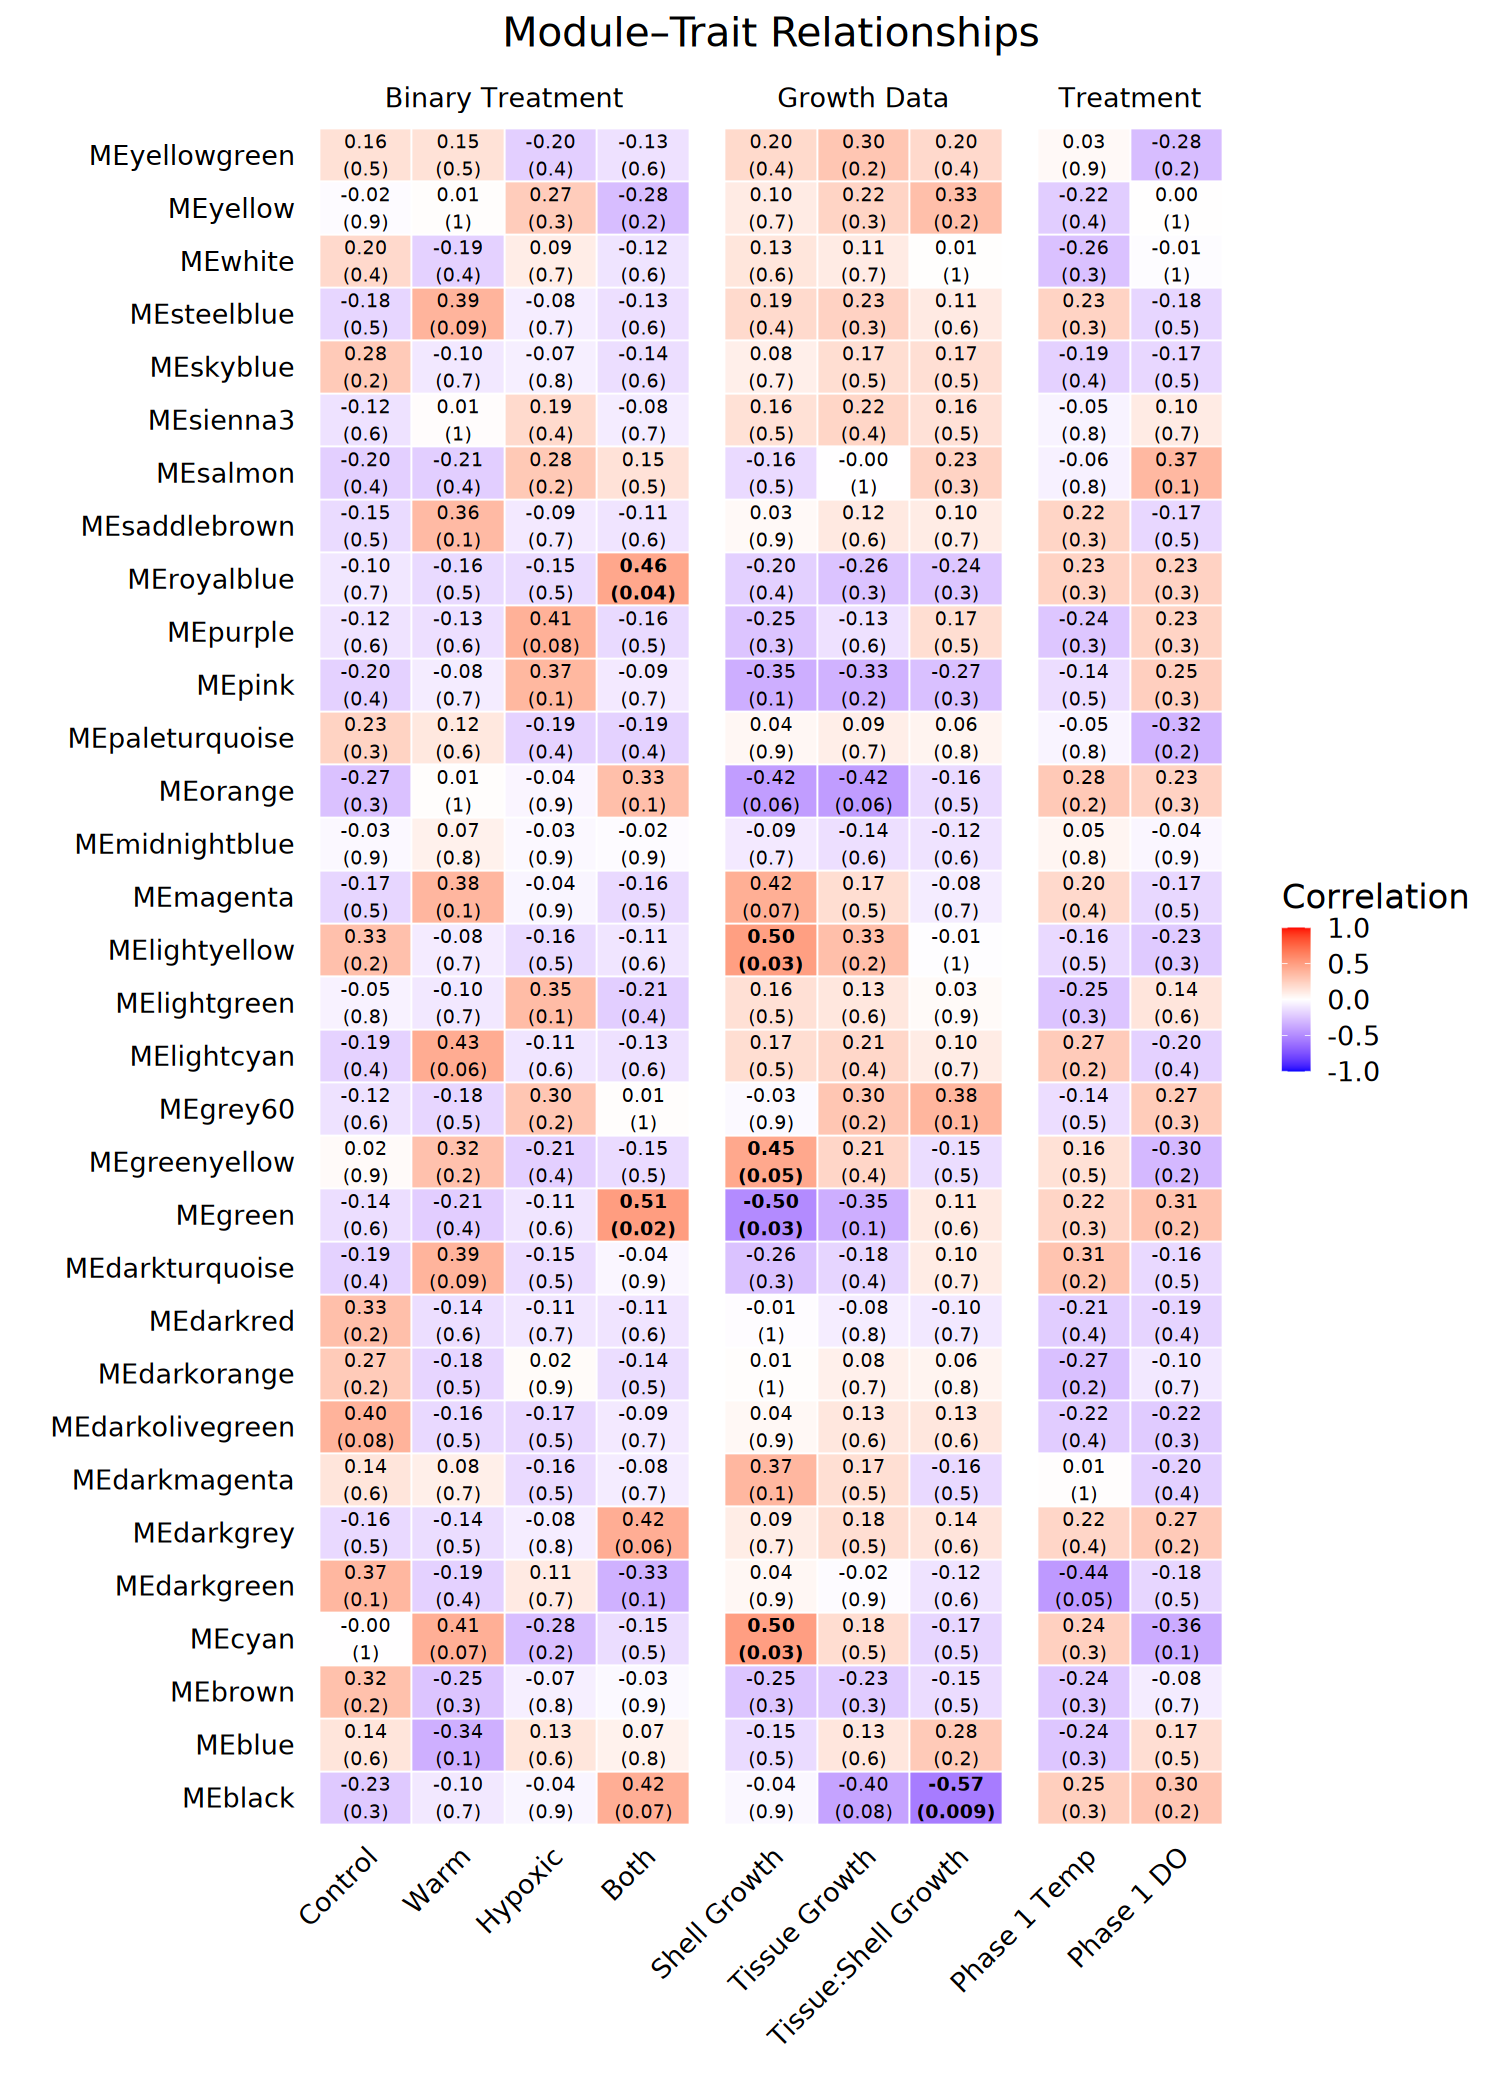

In [62]:
options(repr.plot.width = 12.5, repr.plot.height = 17.5)

# reorder x-axis
trait_order <- c("Shell Growth", "Tissue Growth", "Tissue:Shell Growth", 
                 "Phase 1 Temp", "Phase 1 DO", 
                 "Control", "Warm", "Hypoxic", "Both")
df.clean$Trait <- factor(df.clean$Trait, levels = trait_order)

heatmap1 <- ggplot(df.clean, aes(x = Trait, y = module, fill = Cor)) +
  geom_tile(color = "white") +
  
  # text annotations
  geom_text(
    aes(
      label = label,
      fontface = ifelse(sig, "bold", "plain")
    ),
    size = 4
  ) +
  
  scale_fill_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    limits = c(-1, 1)
  ) +

  facet_grid(
    ~ trait_type,
    scales = "free_x",
    space = "free_x"
  ) +

  theme_minimal(base_size = 20) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = 'black'),
      axis.text.y = element_text(color = 'black'),
    panel.grid = element_blank(),
      plot.title = element_text(hjust = .5),
      strip.text = element_text(color = 'black')
  ) +
  
  labs(
    title = "Module–Trait Relationships",
    x = "",
    y = "",
    fill = "Correlation"
  )

heatmap1

In [81]:
ggsave(
  filename = "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/plots/module_trait_heatmap.png",
  plot = heatmap1,
  width = 12.5,
  height = 15,
  dpi = 300
)

**observations**;
- there's no significantly correlated modules with treatment traits, but a lot of stronly correlated modules with growth-related traits
- lightyellow, greenyellow, and cyan are positively correlated with shell growth (so increased growth is correlated with higher expression in this module)
- green is negatively correlated with shell growth (decreased growth ~ lower expression)
-  black is negatively correlated with the tissue:shell growth ratio (so increased T:S ratio (which indicates more tissue than shell i.e., investment in reproduction) is correlated with decreased expression in this module)

#### phase 1 treatments

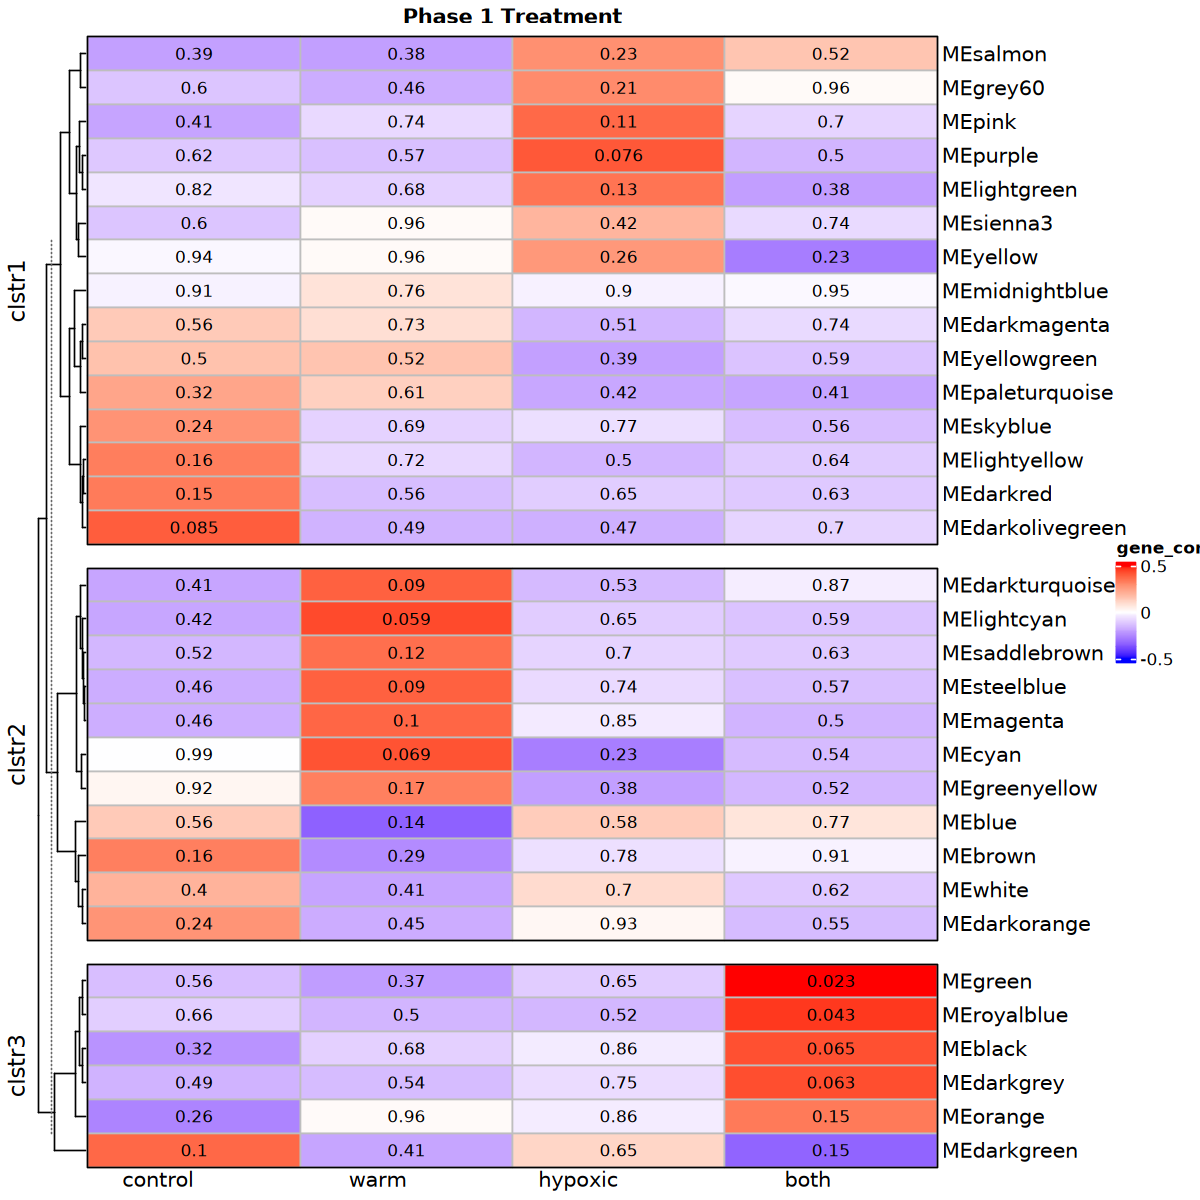

In [82]:
options(repr.plot.width = 10, repr.plot.height = 10)

# Define your desired order based on your actual column names
my_col_order = c("control", "warm", "hypoxic", "both") 

p1.treatment.text <-  as.matrix(signif(moduleTraitPvalue_p1, 4))
# cluster modules based on p-value similarity
pa = cluster::pam(p1.treatment.text, k = 3)
col_fun = colorRamp2(c(-0.5, 0, 0.5), c("blue", "white", "red"))

p1_treatment.heatmap <- Heatmap(moduleTraitCor_p1, 
        column_order = my_col_order,
        name = "gene_cor", 
        rect_gp = gpar(col = "grey", lwd = 1),
        column_title = "Phase 1 Treatment", 
        column_title_gp = gpar(fontsize = 12, fontface = "bold"),
        # row_title = "WGCNA modules",
        #row_km = 4, 
        column_names_rot = 0,
        column_km = 1,
        row_split = paste0("clstr", pa$clustering),
        row_gap = unit(5, "mm"),
        column_gap = unit(5, "mm"),
        # grid.text(matrix(textMatrix)),
        # border = TRUE,
        border = TRUE,
        col = col_fun,
        cell_fun = function(j, i, x, y, width, height, fill) {
          grid.text(sprintf("%.2g", p1.treatment.text[i, j]), x, y,
          gp = gpar(fontsize = 10))
        })

p1_treatment.heatmap

so the color denotes the correlation, the text within the heatmap denotes the p-value

**higher module eigengene-treatment correlation = higher expression of the module with the given trait/treatment**
- red = lower expression in the given treatment
- blue = higher expression in the given treatment


woah lots going on here

BUT what's interesting is that we see sets of modules that are positively correlated with each treatment (only a few are significant; p-value < 0.05)

**control**
- none

**warm**
- mediumpurple3

**hypoxic**
- none

**both**
- green
- darkred
- *almost* red and royalblue

what does this heatmap tell you over looking at just temp or DO - is it the specific interaction of stressors (like warm and hypoxic (both) together is correlated with a module), or is it one stressor in general (warm vs. ambient)?

#### phase 1 temp

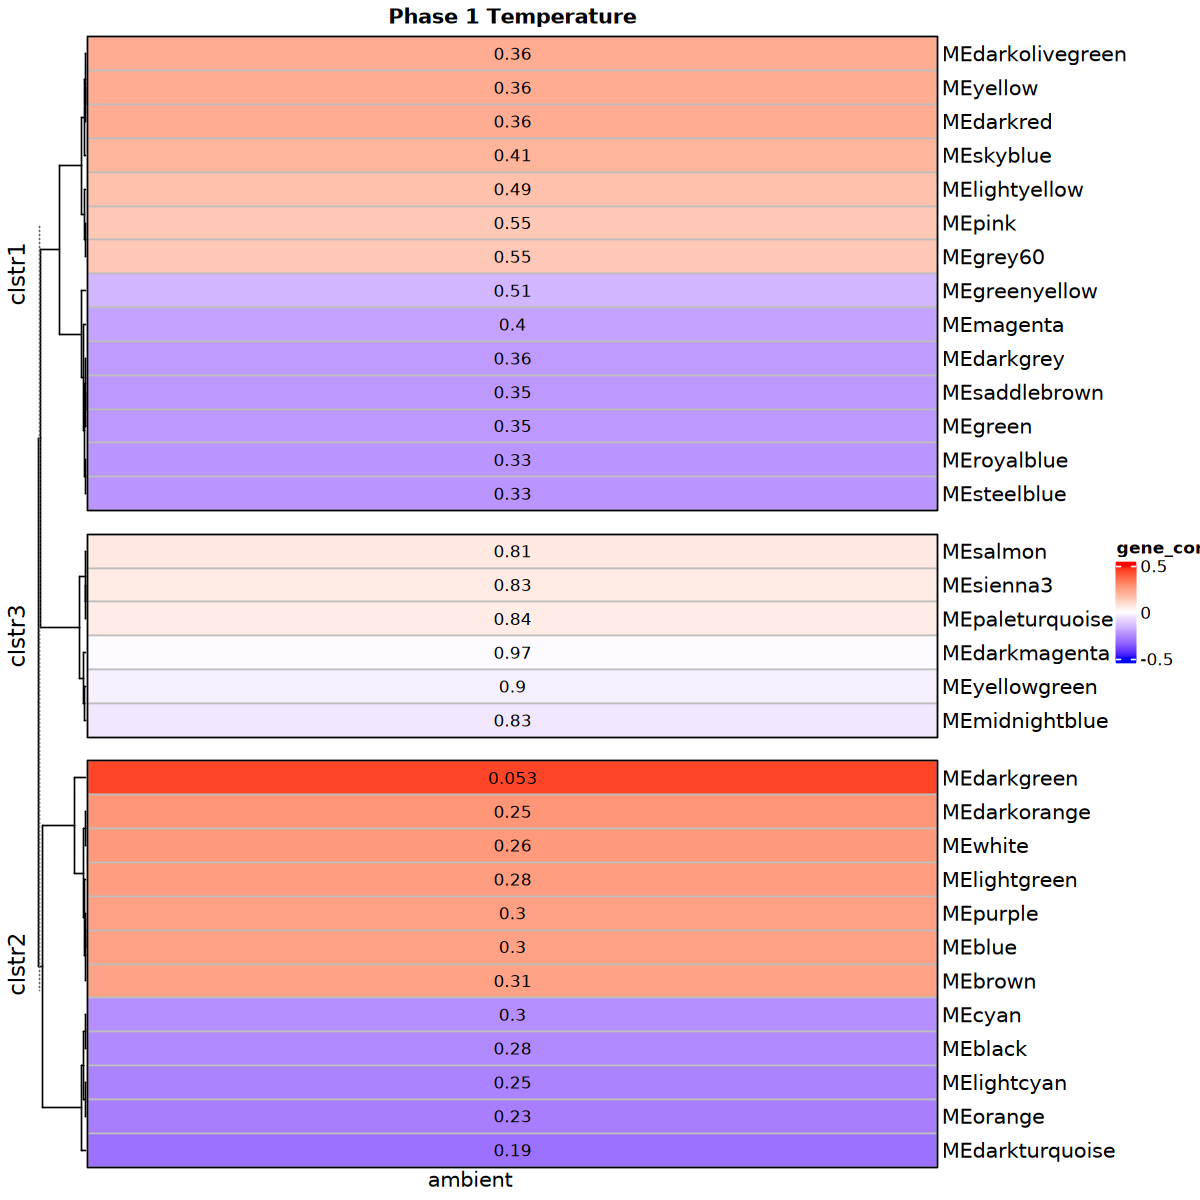

In [83]:
options(repr.plot.width = 10, repr.plot.height = 10)

p1.temp.text <-  as.matrix(signif(moduleTraitPvalue_p1.temp, 4))
# cluster modules based on p-value similarity
pa = cluster::pam(p1.temp.text, k = 3)
col_fun = colorRamp2(c(-0.5, 0, 0.5), c("blue", "white", "red"))

p1_temp.heatmap <- Heatmap(moduleTraitCor_p1.temp, 
        name = "gene_cor", 
        rect_gp = gpar(col = "grey", lwd = 1),
        column_title = "Phase 1 Temperature", 
        column_title_gp = gpar(fontsize = 12, fontface = "bold"),
        # row_title = "WGCNA modules",
        #row_km = 4, 
        column_names_rot = 0,
        column_km = 1,
        row_split = paste0("clstr", pa$clustering),
        row_gap = unit(5, "mm"),
        column_gap = unit(5, "mm"),
        # grid.text(matrix(textMatrix)),
        # border = TRUE,
        border = TRUE,
        col = col_fun,
        cell_fun = function(j, i, x, y, width, height, fill) {
          grid.text(sprintf("%.2g", p1.temp.text[i, j]), x, y,
          gp = gpar(fontsize = 10))
        })

p1_temp.heatmap

no significantly correlated modules (darkgreen but barelyyyy)

#### phase 1 DO

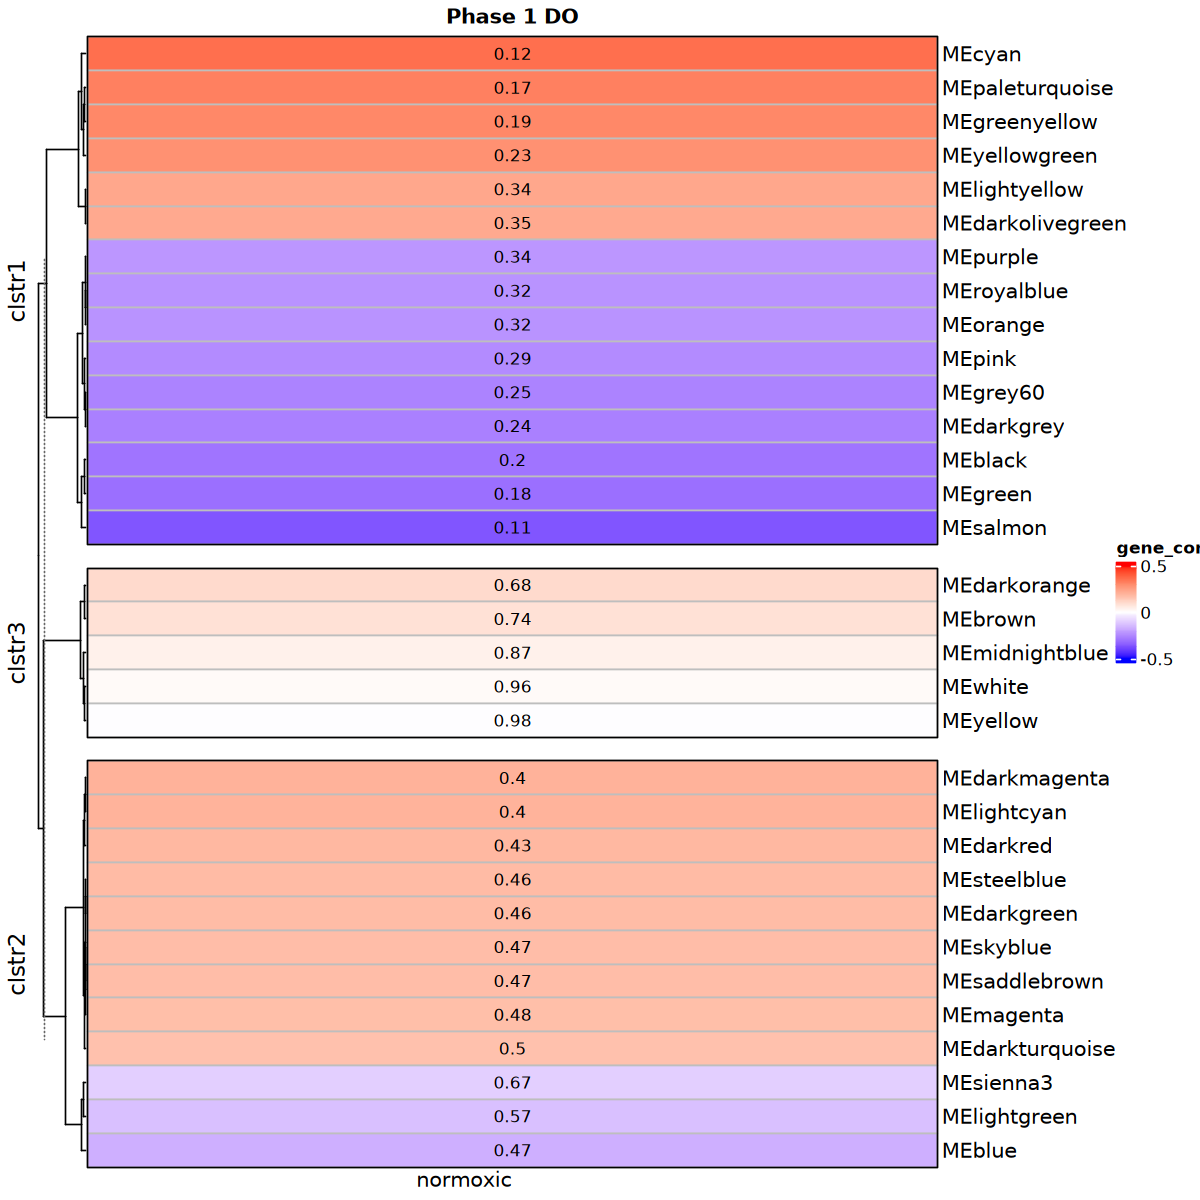

In [84]:
options(repr.plot.width = 10, repr.plot.height = 10)

p1.DO.text <-  as.matrix(signif(moduleTraitPvalue_p1.DO, 4))
# cluster modules based on p-value similarity
pa = cluster::pam(p1.DO.text, k = 3)
col_fun = colorRamp2(c(-0.5, 0, 0.5), c("blue", "white", "red"))

p1_DO.heatmap <- Heatmap(moduleTraitCor_p1.DO, 
        name = "gene_cor", 
        rect_gp = gpar(col = "grey", lwd = 1),
        column_title = "Phase 1 DO", 
        column_title_gp = gpar(fontsize = 12, fontface = "bold"),
        # row_title = "WGCNA modules",
        #row_km = 4, 
        column_names_rot = 0,
        column_km = 1,
        row_split = paste0("clstr", pa$clustering),
        row_gap = unit(5, "mm"),
        column_gap = unit(5, "mm"),
        # grid.text(matrix(textMatrix)),
        # border = TRUE,
        border = TRUE,
        col = col_fun,
        cell_fun = function(j, i, x, y, width, height, fill) {
          grid.text(sprintf("%.2g", p1.DO.text[i, j]), x, y,
          gp = gpar(fontsize = 10))
        })

p1_DO.heatmap

no significantly correlated modules

#### conclusions here:
- no significantly correlated modules

### combine heatmaps to one plot

In [85]:
# 1. Create a helper function to convert ComplexHeatmap to a grob
as_grob_hm <- function(hm) {
  grid.grabExpr(draw(hm))
}

# 2. Convert all your heatmaps
p1_temp_g <- as_grob_hm(p1_temp.heatmap)
p1_DO_g <- as_grob_hm(p1_DO.heatmap)
p1_treatment_g <- as_grob_hm(p1_treatment.heatmap)

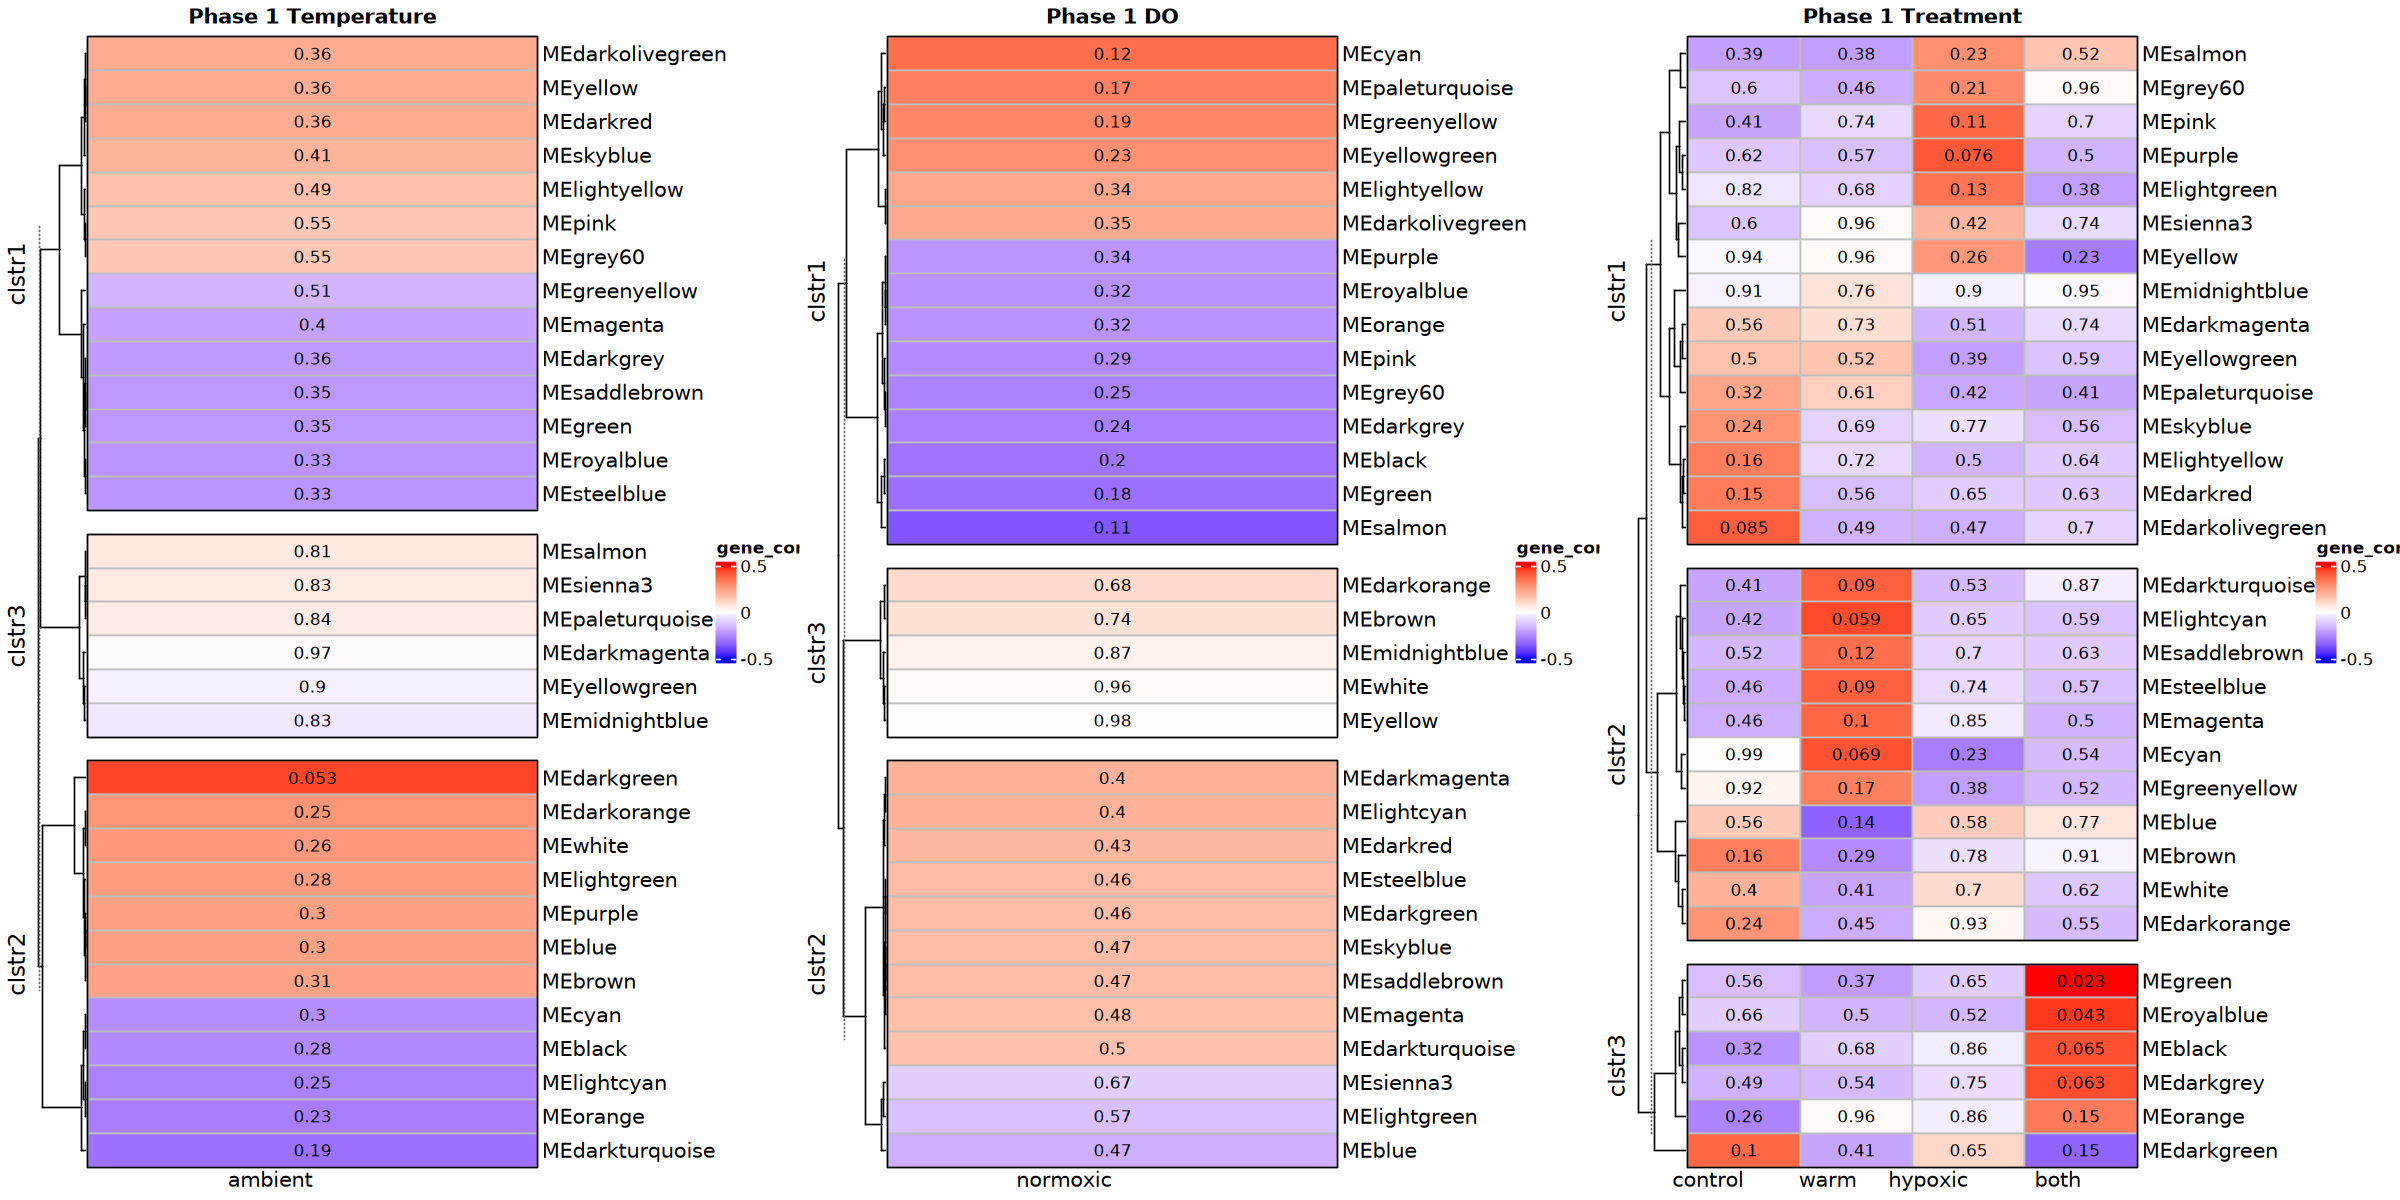

In [86]:
options(repr.plot.width = 20, repr.plot.height = 10)

# 3. Use plot_grid with the new grob objects
all_heatmaps <- plot_grid(p1_temp_g, p1_DO_g, p1_treatment_g,
          nrow = 1, ncol = 3)

all_heatmaps

the only significantly correlated modules are green and royalblue - both are positively regulated for the both ttreatment (so increased expression when oysters experience both stressors, relative to only experience one stressor or no stressors)

In [87]:
ggsave(
  filename = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/plots/p1_heatmap_summary.png', 
  plot = all_heatmaps, 
  width = 20,       # Half the width
  height = 10,     # Roughly half the height
  units = "in", 
  dpi = 300         # High resolution for clarity
)

## MEs boxplots by treatment group

inspo for this comes from [Gurr's code](https://github.com/SamGurr/Pgenerosa_OA_TagSeq/blob/main/TagSeq/Analysis/Scripts/Day21_WGCNA_all.R) - plotting every module's ME (module eigengene) for each treatment combination - this will allow me to take a closer look at the relationship between modules and phase 1 and 2 treatments


then create df to plot boxplots - want the metadata and module eigengene info in long format

In [88]:
# Create ME table
MEs_df <- as.data.frame(MEs)
MEs_df$Sample <- rownames(MEs_df)

# format metadata and merge with MEs
dataMeta2 <- dataMeta[,1:4]
dim(dataMeta2)

# merge MEs and metadata
MEsPlotting <- merge(dataMeta2, MEs_df, by = 'Sample')

# Melt to long format
MEsPlotting_melt <- reshape2::melt(
  MEsPlotting,
  id.vars = c("Sample",
              "Phase1_treatment",
              "Phase1_temp",
              "Phase1_DO"
             ),
  variable.name = "Module",
  value.name = "Eigengene"
)

MEsPlotting_melt <- MEsPlotting_melt %>%
filter(!grepl('code', Module)) # remove treatment code rows

head(MEsPlotting_melt)

[1] 20  4

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Module,Eigengene
,<chr>,<fct>,<fct>,<fct>,<fct>,<dbl>
1,B1_Nu_O03,both,warm,hypoxic,MElightyellow,-0.04666700
2,B4_Nu_O32,both,warm,hypoxic,MElightyellow,-0.04121190
3,B5_Nu_O36,both,warm,hypoxic,MElightyellow,-0.05308644
4,B6_Nu_O47,both,warm,hypoxic,MElightyellow,-0.05621793
5,C1_Nu_W01,control,ambient,normoxic,MElightyellow,0.96940532
6,C1_Nu_W05,control,ambient,normoxic,MElightyellow,-0.04326630


In [89]:
# save metadata in case I skip code above
#write.csv(MEsPlotting_melt, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/p2.wgcna_metadata.csv')

make boxplot!

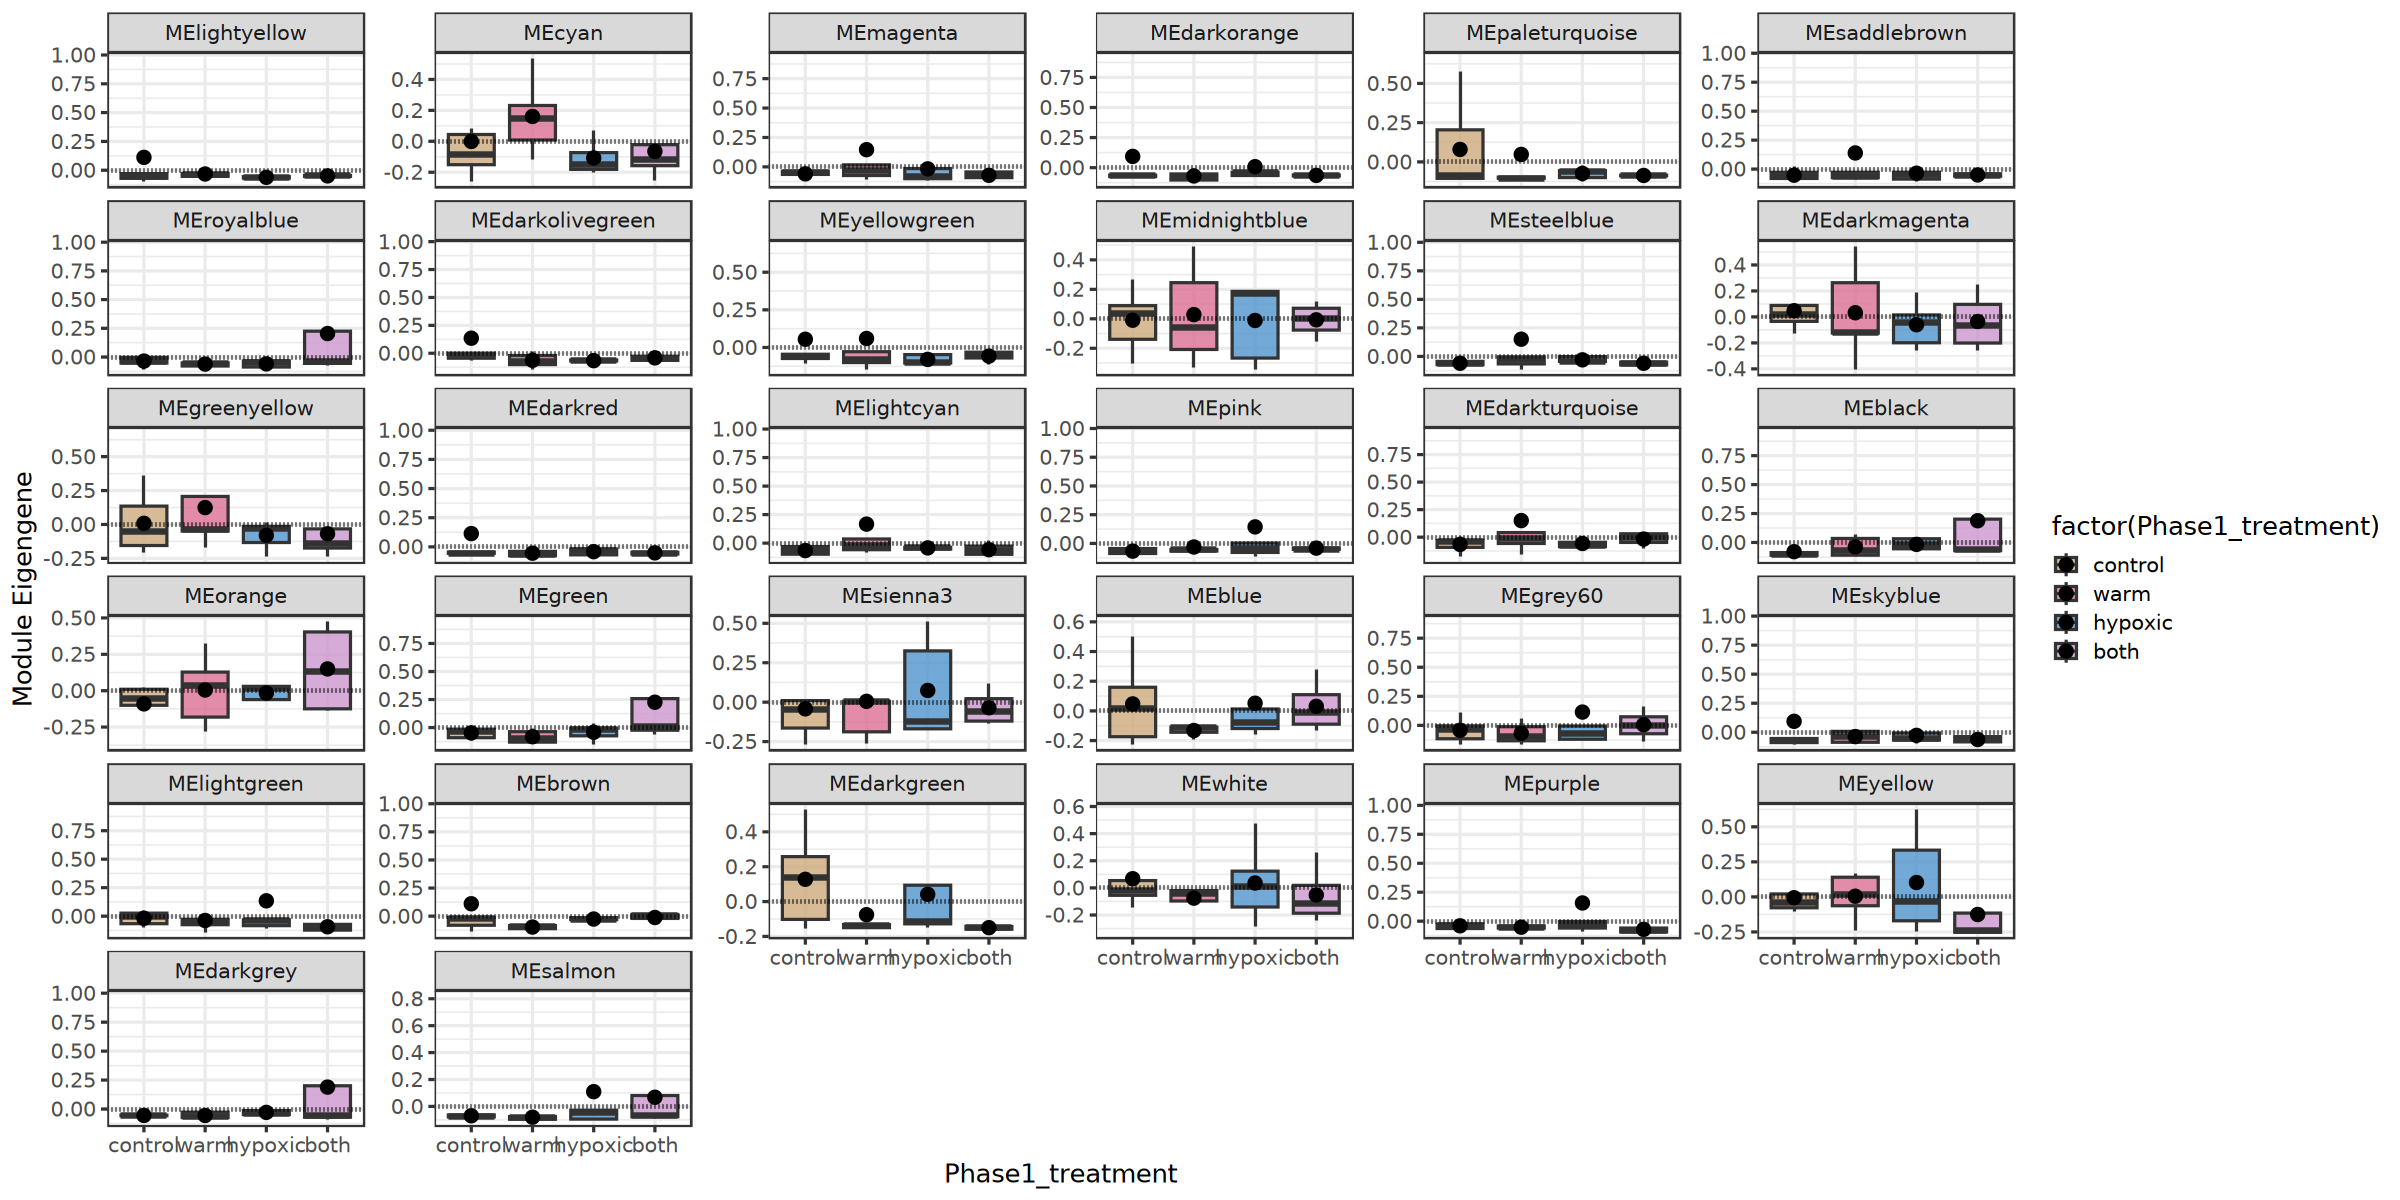

In [90]:
options(repr.plot.width = 20, repr.plot.hieght = 15)

MEsPlotting_melt$Phase1_treatment <- factor(MEsPlotting_melt$Phase1_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

MEs_boxplot <- ggplot(MEsPlotting_melt,
       aes(x = Phase1_treatment,
           y = Eigengene,
           fill = factor(Phase1_treatment))) +
  
  geom_boxplot(position = position_dodge(0.8),
               outlier.shape = NA,
               alpha = 0.8) +

scale_fill_manual(values = c("hypoxic" = "steelblue3", 
                             "warm" = "palevioletred", 
                             "control" = "burlywood3", 
                             "both" = "plum3")) +
  
  stat_summary(fun = mean,
               geom = "point",
               color = "black",
               position = position_dodge(0.8),
               size = 3) +
  
  geom_hline(yintercept = 0,
             linetype = "dotted",
             linewidth = 1) +
  
  ylab("Module Eigengene") +
  theme_bw(base_size=15) +
  facet_wrap(~ Module, scales = "free_y")
MEs_boxplot

since there are so many modules, i'm just going to plot the ones with significant module-trait relationships
- lightyellow
- greenyellow
- cyan
- green
- black
- royalblue

In [91]:
ggsave(
  filename = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/plots/MEs_boxplots_p1.png', 
  plot = MEs_boxplot, 
  width = 20,       # Half the width
  height = 15,     # Roughly half the height
  units = "in", 
  dpi = 300         # High resolution for clarity
)

## 4. Identify hub genes
hub genes = gene with the most connectivity within its module 

In [104]:
hubGenes <- chooseTopHubInEachModule(dataExpr, # vst expr. matrix
                         mergedColors_sign, # from dendogram above
                         omitColors = "grey", # grey module = genes not assigned to any module
                         power = 5, 
                         type = "signed")

# make into df, assign modules in column
hubGenes.df <- as.data.frame(hubGenes) %>%
mutate(module = rownames(.))
# remove row names
rownames(hubGenes.df) <- NULL

hubGenes.df

hubGenes,module
<chr>,<chr>
LOC111105145,black
LOC111132145,blue
LOC111119883,brown
LOC111113217,cyan
LOC111106376,darkgreen
LOC111135300,darkgrey
LOC111126503,darkmagenta
LOC144626571,darkolivegreen
LOC144621404,darkorange


from the heatmap and boxplots above, the modules I'm most interested is:

**positive correlation with shell growth**
- **lightyellow**: [LOC111106457](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111106457), uncharacterized
- **greenyellow**: [LOC111129496](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111129496), small nuclear ribonucleoprotein Sm D2
    - involved in RNA binding and RNA splicing
    - central part of spliceosome
- **cyan**: [LOC111113217](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111113217), importin subunit beta-1-like
    - enables small GTPase binding
    - involved in protein import into nucleus

**negative correlation with shell growth**
- **green**: [LOC111116371](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111116371), uncharacterized

**negative correlation with tissue:shell growth**
- **black**: [LOC111105145](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111105145), cystatin-A-like
    - involved in the immune response in oysters ([source](https://www-sciencedirect-com.umasslowell.idm.oclc.org/science/article/pii/S105046481830041X))
 
**positive correlation with both treatment (compared to not both; H, W, or C)**
- **green**: [LOC111116371](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111116371), uncharacterized
- **royalblue**: [LOC111125226](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111125226), uncharacterized

## 5. Gene significance (GS) and module membership (MM)
both are critical metrics for identifying hub genes within modules that are associated with specific treatment/traits
- GS = correlates gene expression with treatment/trait
- MM = how well a gene belongs to a module

basically select a module of interest and validate with GS and MM - combine GS and MM to find genes that are highly connected *and* strongly associated with the treatment/trait

In [92]:
modNames <- substring(names(MEs), 3)
modNames

[1] "lightyellow"    "cyan"           "magenta"        "darkorange"    
 [5] "paleturquoise"  "saddlebrown"    "royalblue"      "darkolivegreen"
 [9] "yellowgreen"    "midnightblue"   "steelblue"      "darkmagenta"   
[13] "greenyellow"    "darkred"        "lightcyan"      "pink"          
[17] "darkturquoise"  "black"          "orange"         "green"         
[21] "sienna3"        "blue"           "grey60"         "skyblue"       
[25] "lightgreen"     "brown"          "darkgreen"      "white"         
[29] "purple"         "yellow"         "darkgrey"       "salmon"

#### module membership
MM is the same across all treatments

In [93]:
geneModuleMembership = as.data.frame(cor(dataExpr, MEs, use = "p"))
MMPvalue = as.data.frame(corPvalueStudent(as.matrix(geneModuleMembership), nSamples))

names(geneModuleMembership) = paste("MM", modNames, sep="")
names(MMPvalue) = paste("p.MM", modNames, sep="")

In [94]:
head(geneModuleMembership)

,MMlightyellow,MMcyan,MMmagenta,MMdarkorange,MMpaleturquoise,MMsaddlebrown,MMroyalblue,MMdarkolivegreen,MMyellowgreen,MMmidnightblue,⋯,MMgrey60,MMskyblue,MMlightgreen,MMbrown,MMdarkgreen,MMwhite,MMpurple,MMyellow,MMdarkgrey,MMsalmon
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621260,-0.10442110,-0.03827248,0.05767382,-0.24035885,0.114251204,0.17879465,-0.227625449,0.17745083,0.05552680,0.0600548,⋯,-0.35494456,0.18269917,0.2809994,0.09877884,0.38335675,0.2704473,0.45728846,0.40847091,-0.189351807,-0.328529000
LOC144621269,0.28424785,0.14174422,0.06103181,-0.15808666,-0.095654949,0.01486596,-0.215467242,-0.18839892,-0.28003309,-0.2260378,⋯,-0.19594705,-0.04015417,0.3257397,-0.15147049,-0.03188501,0.2413112,0.53846275,0.93441992,0.352025315,0.055921273
LOC111120925,-0.15073534,-0.24064045,0.09670025,-0.15952101,-0.128704086,-0.10829886,-0.052501430,0.09249688,-0.07524131,-0.4232081,⋯,-0.06674539,0.09617796,0.2109341,0.95152516,0.76999434,0.6757217,-0.06769600,-0.05251611,-0.103302762,-0.139590718
LOC144621283,0.01187496,0.21347721,0.51013554,-0.04783975,0.013902585,0.04333737,-0.083804188,-0.18935910,-0.09242026,-0.1315841,⋯,-0.28680515,0.14618753,0.1755457,0.11111924,0.21488102,0.4061947,-0.14697154,-0.08735730,0.192323709,0.001006270
LOC144621276,-0.30386385,-0.07492016,0.35423969,-0.08998786,-0.003510896,-0.02533059,-0.001514913,0.15967946,0.36748896,-0.1371159,⋯,-0.15962320,0.06650523,0.3590967,0.10292780,0.28397820,0.6796537,0.03211756,0.20138724,0.516209183,0.347835746
LOC111115920,0.08873369,-0.03866644,-0.25206305,-0.09619323,-0.192578182,-0.15342659,0.216288157,-0.12472658,-0.15516924,0.3305097,⋯,-0.05082227,-0.10919068,-0.3639306,-0.28995272,-0.44958128,-0.4789458,0.06324367,-0.30900131,0.006507563,-0.006662961


#### gene significance
calculated for each treatment combination

In [95]:
# List all trait sets you want to process
trait_sets <- list(
  phase1_temp = phase1.temp[-1],
  phase1_DO = phase1.DO[-1],
    phase1_treatment = phase1.treatments[-1]
)

# Initialize lists to store results
geneTraitSignificance_all <- list()
GSPvalue_all <- list()

# Loop over each trait set
for(set_name in names(trait_sets)){
  traits_df <- trait_sets[[set_name]]
  
  # Get trait names
  trait_names <- colnames(traits_df)
  
  # Initialize lists for this set
  gs_list <- list()
  gs_p_list <- list()
  
  for(trt in trait_names){
    trt_df <- as.data.frame(traits_df[[trt]])
    names(trt_df) <- trt
    
    # Compute gene-trait significance and p-values
    gs <- as.data.frame(cor(dataExpr, trt_df, use = "p"))
    gs_p <- as.data.frame(corPvalueStudent(as.matrix(gs), nSamples))
    
    # Rename columns
    names(gs) <- paste0("GS.", trt)
    names(gs_p) <- paste0("p.GS.", trt)
    
    # Store in lists
    gs_list[[trt]] <- gs
    gs_p_list[[trt]] <- gs_p
  }
  
  # Combine into data frames for this set
  geneTraitSignificance_all[[set_name]] <- do.call(cbind, gs_list)
  GSPvalue_all[[set_name]] <- do.call(cbind, gs_p_list)
}

# Optional: combine all sets into one big data frame each
geneTraitSignificance_df <- do.call(cbind, geneTraitSignificance_all)
GSPvalue_df <- do.call(cbind, GSPvalue_all)

In [96]:
head(geneTraitSignificance_df) 

,GS.ambient,GS.normoxic,phase1_treatment.GS.both,phase1_treatment.GS.control,phase1_treatment.GS.hypoxic,phase1_treatment.GS.warm
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621260,0.02793148,0.09063762,-0.24527723,-0.08537449,0.12244270,0.19448657
LOC144621269,0.01878347,0.06031195,-0.22004509,-0.10620351,0.13397579,0.18168838
LOC111120925,0.32245181,0.25157372,-0.21687858,0.43386662,-0.08869235,-0.17012507
LOC144621283,-0.25902844,0.15348297,0.25464137,0.10768691,-0.41156613,0.06237339
LOC144621276,-0.08695448,-0.05054218,0.03367157,-0.11987821,0.02696408,0.06879863
LOC111115920,-0.28287248,-0.49802101,0.71366842,-0.22481296,-0.08707607,-0.33426291


In [97]:
colnames(geneTraitSignificance_df)

[1] "GS.ambient"                  "GS.normoxic"                
[3] "phase1_treatment.GS.both"    "phase1_treatment.GS.control"
[5] "phase1_treatment.GS.hypoxic" "phase1_treatment.GS.warm"

In [100]:
annot <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/newRef_geneGO.csv')
colnames(annot)[1] <- 'Gene'
colnames(annot)[2] <- 'GO.terms'
head(annot)

,Gene,GO.terms
,<chr>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655
2,LOC111099032,GO:0004930;GO:0005886;GO:0007186
3,LOC111099037,GO:0000978;GO:0000981;GO:0006355
4,LOC111099039,GO:0004930;GO:0005886;GO:0007189
5,LOC111099040,GO:0005515;GO:0007169;GO:0035556
6,LOC111099041,GO:0016020;GO:0022857;GO:0055085


In [101]:
# 1. Create a data frame for gene information
# Ensure the names of the vector match your gene names
gene_info <- data.frame(
  Gene = colnames(dataExpr),
  ModuleColor = mergedColors_sign
)

# 2. Bind it with  MM and GS dataframes
# (Assuming these have genes as row names in the same order)
final_results <- cbind(gene_info, geneTraitSignificance_df, GSPvalue_df, geneModuleMembership)

# 3. Add GO terms
final_res <- merge(annot, final_results, by = 'Gene')

# 3. Take a look
head(final_res)

,Gene,GO.terms,ModuleColor,GS.ambient,GS.normoxic,phase1_treatment.GS.both,phase1_treatment.GS.control,phase1_treatment.GS.hypoxic,phase1_treatment.GS.warm,p.GS.ambient,⋯,MMgrey60,MMskyblue,MMlightgreen,MMbrown,MMdarkgreen,MMwhite,MMpurple,MMyellow,MMdarkgrey,MMsalmon
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,magenta,-0.35380574,0.12117253,0.01413832,-0.24021041,-0.15227705,0.39343144,0.1259224,⋯,0.03234708,0.21072791,0.10579276,-0.253432155,0.059511636,-0.03521488,-0.24476817,-0.13443160,0.07193762,0.04142548
2,LOC111099040,GO:0005515;GO:0007169;GO:0035556,grey60,0.38543189,0.22119072,-0.48185106,0.23796773,0.19098616,0.00228741,0.0932918,⋯,0.49605329,0.04238787,-0.15141525,0.130092136,0.123516087,-0.12941687,-0.12077803,-0.28899429,-0.20576952,-0.09785979
3,LOC111099041,GO:0016020;GO:0022857;GO:0055085,pink,0.04271455,-0.31134169,0.11758188,-0.18899321,0.24908689,-0.15769276,0.8580899,⋯,-0.01006947,-0.03562632,-0.28534030,-0.095151830,-0.171128226,-0.43014690,-0.04595866,-0.21603454,0.11164322,0.25712188
4,LOC111099043,GO:0005222;GO:0005223;GO:0005886;GO:0017071;GO:0030553;GO:0044877;GO:0098655,black,0.29992706,-0.06425273,-0.22576188,0.05879171,0.28237065,-0.13604006,0.1988723,⋯,0.17477011,0.23733611,0.15190315,-0.162191108,0.016913880,-0.19914462,0.36747715,0.31683154,-0.15683078,-0.03143776
5,LOC111099050,GO:0005515;GO:0006886;GO:0031462;GO:0043161;GO:1990756,grey60,0.14429745,-0.19812526,0.14214034,0.06563370,0.09632497,-0.29708878,0.5438798,⋯,0.54839515,0.10911711,-0.09058304,0.005681654,-0.005374575,-0.36051894,-0.04986036,-0.35245538,-0.43384568,-0.29787464
6,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,cyan,-0.33772029,0.42418002,-0.07947776,0.02448856,-0.41392732,0.46142948,0.1453172,⋯,-0.14412849,0.02832059,0.15737953,-0.084139786,0.150425993,-0.02658092,-0.22855601,-0.09548234,-0.41735822,-0.53034024


In [103]:
#write.csv(final_res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/p1.wgcna_GeneInfo.csv', row.names = FALSE)